# StaticKD: *Knowledge Distillation* Pengklasifikasi Topik Berita IPTC Multibahasa ke Tabel Logit Token Statis untuk Inferensi Ringan di CPU

**Notebook implementasi dan hasil penelitian.** Setiap angka, tabel, dan gambar di jurnal
(`jurnal_latex/main.tex`) dihasilkan oleh notebook ini. Bagian 11 menulis angka-angka tersebut ke
`jurnal_latex/generated/`, dan LaTeX membacanya dari sana, sehingga tidak ada angka yang diketik manual.

| | |
|---|---|
| Penulis | Obi Kastanya, Ananta Dwi Prayoga Alwy |
| Teacher | `classla/multilingual-IPTC-news-topic-classifier` (Kuzman & Ljubešić, IEEE Access 2025) |
| Metode usulan | StaticKD: knowledge distillation ke tabel 17 logit per token |
| Kode | paket `src/statickd/` (diimpor oleh notebook ini) dan skrip `scripts/` |

## Daftar isi

0. [Cara memakai notebook](#0)
1. [Setup lingkungan](#1)
2. [Tugas: taksonomi IPTC Media Topic](#2)
3. [Data](#3): data distilasi, set *development*, set uji gabungan 47 bahasa
4. [Teacher](#4)
5. [Metode StaticKD langkah demi langkah](#5)
6. [Training StaticKD dan baseline](#6)
7. [Protokol evaluasi dan uji statistik](#7)
8. [Hasil akurasi (RQ2)](#8)
9. [Ablasi, temperature, dan ensemble (RQ3)](#9)
10. [Efisiensi CPU (RQ1) dan analisis generalisasi (RQ4)](#10)
11. [Ekspor angka, tabel, dan gambar ke jurnal](#11)
12. [Keterbatasan dan catatan reproduktibilitas](#12)

**Pertanyaan penelitian**

- **RQ1 (biaya).** Berapa biaya inferensi CPU teacher, dan berapa besar StaticKD menurunkannya?
- **RQ2 (akurasi).** Seberapa besar akurasi teacher yang dipertahankan StaticKD pada label yang independen
  dari teacher, dibanding baseline berbiaya serupa (fastText, TF-IDF + SVM) dan berbiaya lebih tinggi
  (MiniLM-L6, DistilmBERT)?
- **RQ3 (komponen).** Komponen distilasi apa yang menentukan hasil pada student berkapasitas sangat rendah?
- **RQ4 (generalisasi).** Di bahasa, label, dan sumber label mana StaticKD lemah, dan mengapa?

<a id="0"></a>
## 0. Cara memakai notebook

Langkah berat (pengunduhan data, pelabelan teacher, training, benchmark) dijalankan oleh skrip di
`scripts/` dan hasilnya disimpan di `data/`, `models/`, dan `results/final/`. Saklar `RUN_*` di sel berikut
menentukan apakah suatu langkah dihitung ulang dari nol (`True`) atau hasil tersimpan yang dipakai
(`False`, bawaan). Dengan semua saklar `False`, notebook selesai dalam beberapa menit dan menghasilkan
ulang seluruh tabel dan gambar dari prediksi yang tersimpan.

| Saklar | Langkah | Perkiraan waktu (RTX 4050 + Core Ultra 7) |
|---|---|---|
| `RUN_CORPUS` | unduh korpus distilasi CC-News 2019–2021 (69 bahasa) | ±1 jam |
| `RUN_TESTSET` | unduh WARC CC-NEWS 2024–2026 (±34 GB), ekstraksi JSON-LD, dataset publik, bangun set uji | ±6 jam |
| `RUN_TEACHER_LABELS` | pelabelan 300 ribu dokumen oleh teacher (GPU) | ±1,5 jam |
| `RUN_TRAINING` | 72 run StaticKD (ablasi, seed) | ±3 jam |
| `RUN_BASELINES` | fastText, TF-IDF + SVM | ±1 jam |
| `RUN_TRANSFORMERS` | MiniLM-L6 + KD dan DistilmBERT + KD (GPU) | ±3 jam |
| `RUN_EVAL_TEACHER` | prediksi teacher di set evaluasi (GPU dan CPU ONNX) | ±1,5 jam |
| `RUN_BENCHMARK` | benchmark CPU semua model (mesin harus idle) | ±1 jam |

In [1]:
RUN_CORPUS = False
RUN_TESTSET = False
RUN_TEACHER_LABELS = False
RUN_TRAINING = False
RUN_BASELINES = False
RUN_TRANSFORMERS = False
RUN_EVAL_TEACHER = False
RUN_BENCHMARK = False
N_BOOT = 1000   # bootstrap resamples for confidence intervals (2000 for paired tests)

<a id="1"></a>
## 1. Setup lingkungan

Notebook mengimpor paket `statickd` dari `src/`. Fungsi `run_script` menjalankan skrip di proses terpisah
(dengan `PYTHONPATH=src`) dan menampilkan output-nya, sehingga langkah berat tidak memenuhi memori kernel.

In [2]:
import json, os, subprocess, sys, time, platform, warnings
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
warnings.filterwarnings("ignore")
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "statickd").exists())  # project root
sys.path.insert(0, str(ROOT / "src"))
os.chdir(ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from statickd import config, data, evaluation as ev, analysis as an, viz
from statickd.config import LABELS, SHORT_LABELS, NUM_LABELS, FINAL_DIR
from statickd.report import Numbers, fmt, fmt_p, write_table

viz.apply_style()
pd.set_option("display.max_columns", 40, "display.width", 200, "display.float_format", "{:.4f}".format)
NUM = Numbers()   # every number that appears in the paper is registered here (Section 11)


def run_script(script: str, *args: str) -> None:
    # Run scripts/<script> (or `-m module`) in a fresh process and stream its output.
    cmd = [sys.executable, "-u", *(["-m", script] if not script.endswith(".py") else [str(ROOT / "scripts" / script)]), *args]
    env = {**os.environ, "PYTHONPATH": str(ROOT / "src")}
    with subprocess.Popen(cmd, cwd=ROOT, env=env, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True) as proc:
        for line in proc.stdout:
            print(line, end="")
    if proc.returncode:
        raise RuntimeError(f"{script} failed ({proc.returncode})")


def show(df, caption=None, digits=4):
    if caption:
        display(Markdown(f"**{caption}**"))
    display(df.style.format(precision=digits, thousands=".", decimal=",") if isinstance(df, pd.DataFrame) else df)

In [3]:
import importlib.metadata as md_
import torch
info = {
    "python": platform.python_version(), "os": platform.platform(),
    "cpu": platform.processor(), "logical_cpus": os.cpu_count(),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none",
    **{pkg: md_.version(pkg) for pkg in ["numpy", "pandas", "scikit-learn", "scipy", "torch", "transformers",
                                          "tokenizers", "onnxruntime", "fasttext-wheel", "datasketch", "trafilatura"]},
}
FINAL_DIR.mkdir(parents=True, exist_ok=True)
(FINAL_DIR / "environment.json").write_text(json.dumps(info, indent=1))
pd.Series(info, name="versi").to_frame()

,versi
python,3.12.4
os,Windows-11-10.0.26200-SP0
cpu,"Intel64 Family 6 Model 170 Stepping 4, Genuine..."
logical_cpus,22
gpu,NVIDIA GeForce RTX 4050 Laptop GPU
numpy,2.5.3
pandas,3.0.6
scikit-learn,1.9.1
scipy,1.18.1
torch,2.6.0+cu124


<a id="2"></a>
## 2. Tugas: taksonomi IPTC Media Topic

IPTC Media Topic adalah taksonomi berita dari International Press Telecommunications Council. Level
teratasnya punya 17 topik. Tugasnya adalah klasifikasi *single-label*: setiap artikel (judul + isi, 512
kata pertama) diberi satu dari 17 label tersebut, sama seperti Kuzman & Ljubešić (2025). Urutan label di
bawah dipakai oleh semua model dan tabel.

In [4]:
iptc = pd.DataFrame(json.loads((ROOT / "src/statickd/testset/iptc_reference/mediatopic_en-GB.json").read_text(encoding="utf8")))
active = iptc[~iptc["retired"]]
from statickd.testset.iptc_map import IPTC_TOP
label_table = pd.DataFrame({"label": LABELS, "singkatan": SHORT_LABELS,
                            "subtopik aktif": [int((active.top_name == IPTC_TOP[l]).sum()) - 1 for l in LABELS]})
NUM.add("iptc.nodes", len(active), 0)
NUM.add("iptc.version_nodes", len(iptc), 0)
show(label_table, "17 label IPTC level atas dan jumlah subtopiknya di pohon IPTC")

**17 label IPTC level atas dan jumlah subtopiknya di pohon IPTC**

,label,singkatan,subtopik aktif
0,"arts, culture, entertainment and media",arts,72
1,"conflict, war and peace",conflict,28
2,"crime, law and justice",crime,66
3,"disaster, accident and emergency incident",disaster,28
4,"economy, business and finance",economy,204
5,education,education,22
6,environment,environment,25
7,health,health,48
8,human interest,human int.,13
9,labour,labour,26


<a id="3"></a>
## 3. Data

Penelitian ini memakai empat jenis data dengan peran yang berbeda. Pemisahan peran ini penting agar
evaluasi akhir tidak bocor.

| Set | Isi | Label | Peran |
|---|---|---|---|
| Data distilasi | EMMediaTopic *train* (4 bahasa) + CC-News 2019–2021 (69 bahasa) | logit teacher | training student |
| *Development* | EMMediaTopic *dev* (1.000 dok, 4 bahasa) | GPT-4o | pemilihan resep |
| *Fidelity* | CC-News *held-out* (12.554 dok dari situs yang tidak pernah dilihat) | prediksi teacher | kemiripan dengan teacher |
| **Uji akhir** | Set uji gabungan (12.744 dok, 47 bahasa, 2024–2026 + dataset publik) | manusia / penerbit | semua klaim akurasi |

### 3.1 EMMediaTopic 1.0

EMMediaTopic (Kuzman & Ljubešić, 2025; CLARIN.SI `11356/1991`) berisi 21.000 artikel berbahasa Katalan,
Yunani, Kroasia, dan Slovenia yang dilabeli GPT-4o. *Teacher* di-*fine-tune* pada 15.000 artikel dari split
*train*. Split *dev* (1.000 artikel) tidak pernah dipakai melatih teacher maupun student, sehingga menjadi
set *development* yang adil untuk keduanya.

In [5]:
emm = data.load_emmediatopic()
emm_stats = emm.groupby(["split", "lang"]).size().unstack(fill_value=0)
emm_stats["total"] = emm_stats.sum(axis=1)
dev = emm[emm.split == "dev"]
NUM.add("emm.train", int((emm.split == "train").sum()), 0)
NUM.add("emm.dev", len(dev), 0)
NUM.add("emm.dev.words", float(dev.text.str.split().str.len().median()), 0)
show(emm_stats, "EMMediaTopic: dokumen per split dan bahasa")

**EMMediaTopic: dokumen per split dan bahasa**

lang,ca,el,hr,sl,total
split,,,,,
dev,250,250,250,250,1.000
train,5.000,5.000,5.000,5.000,20.000


### 3.2 Korpus distilasi CC-News multibahasa

Teacher dapat melabeli berita dalam bahasa apa pun tanpa biaya anotasi. Karena itu korpus distilasi
diambil dari CC-News 2019–2021 (dataset `CloverSearch/cc-news-mutlilingual`, per bahasa) dengan aturan
berikut:

1. Dokumen hanya dipakai jika bahasa di metadata sama dengan hasil fastText-LID.
2. Teks = judul + isi, minimal 75 kata (200 karakter untuk zh/ja/th/my), dipotong ke 512 kata.
3. Maksimal 150 dokumen per situs, supaya satu situs tidak mendominasi.
4. Split *held-out* dibuat **per domain**: seluruh dokumen dari sebagian situs disisihkan (maksimal 20% per
   bahasa), sehingga *held-out* mengukur generalisasi ke situs berita yang belum pernah dilihat.
5. Dokumen tambahan (maksimal 5.000 per bahasa, maksimal 400 per situs) diambil dari situs *train*, tidak
   pernah dari domain *held-out*.

In [6]:
if RUN_CORPUS:
    run_script("statickd.corpus.ccnews", "--per-lang", "3000", "--heldout", "300")
    run_script("statickd.corpus.expand", "--extra", "5000")

pool = data.load_distillation_pool()
heldout = data.load_ccnews_heldout()
pool_langs = pool["lang"].value_counts()
corpus_summary = pd.DataFrame({
    "dokumen": [int((pool.source == s).sum()) for s in ("emmediatopic", "ccnews", "ccnews_extra")] + [len(pool), len(heldout)],
    "bahasa": [pool[pool.source == s].lang.nunique() for s in ("emmediatopic", "ccnews", "ccnews_extra")] + [pool.lang.nunique(), heldout.lang.nunique()],
    "situs": [pool[pool.source == s].domain.nunique() for s in ("emmediatopic", "ccnews", "ccnews_extra")] + [pool.domain.nunique(), heldout.domain.nunique()],
}, index=["EMMediaTopic train", "CC-News train", "CC-News tambahan", "total data distilasi", "CC-News held-out"])
overlap_sites = set(pool.domain) & set(heldout.domain)
strict = ev.eval_view("heldout")
print(f"situs held-out yang juga muncul di data distilasi (di bahasa lain, mis. bbc.com): {len(overlap_sites)} "
      f"-> {len(heldout) - len(strict)} dokumen dikeluarkan; held-out yang dinilai: {len(strict)} dokumen, "
      f"{strict.lang.nunique()} bahasa, {strict.domain.nunique()} situs")
NUM.add("data.heldout.strict", len(strict), 0); NUM.add("data.heldout.strict.langs", strict.lang.nunique(), 0)
NUM.add("data.heldout.strict.sites", strict.domain.nunique(), 0)
for key, row in zip(["emm", "cc", "ccextra", "pool", "heldout"], corpus_summary.itertuples()):
    NUM.add(f"data.{key}.docs", row.dokumen, 0); NUM.add(f"data.{key}.langs", row.bahasa, 0)
NUM.add("data.pool.sites", int(pool[pool.source != "emmediatopic"].domain.nunique()), 0)
NUM.add("data.pool.words", float(pool.text.str.split().str.len().median()), 0)
show(corpus_summary, "Korpus distilasi dan held-out")

situs held-out yang juga muncul di data distilasi (di bahasa lain, mis. bbc.com): 19 -> 995 dokumen dikeluarkan; held-out yang dinilai: 12554 dokumen, 63 bahasa, 217 situs


**Korpus distilasi dan held-out**

,dokumen,bahasa,situs
EMMediaTopic train,20.000,4,1
CC-News train,109.842,69,2.832
CC-News tambahan,156.157,50,2.198
total data distilasi,285.999,69,2.961
CC-News held-out,13.549,68,236


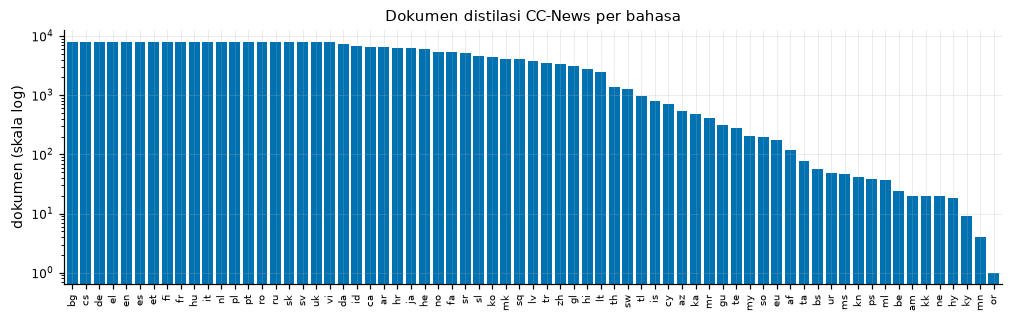

In [7]:
fig, ax = plt.subplots(figsize=(11, 3.0))
counts = pool[pool.source != "emmediatopic"].lang.value_counts()
ax.bar(counts.index, counts.values, color=viz.COLORS["statickd"], width=0.8)
ax.set_yscale("log"); ax.set_ylabel("dokumen (skala log)"); ax.set_xlim(-0.6, len(counts) - 0.4)
ax.tick_params(axis="x", rotation=90, labelsize=6.5)
ax.set_title("Dokumen distilasi CC-News per bahasa")
viz.show_and_save(fig, "fig_distil_per_language")

### 3.3 Set uji gabungan 47 bahasa

Test set manusia Kuzman & Ljubešić tidak publik dan hanya mencakup 4 bahasa. Karena itu kami membangun set
uji multibahasa dengan **label yang independen dari teacher**. Semua sumber diproses dengan pipeline yang
sama.

**(a) CC-NEWS 2024–2026 dengan rubrik JSON-LD.** Satu file WARC per bulan (Januari 2024 – Agustus 2026,
32 file, ±34 GB) diunduh dari Common Crawl. Dari setiap halaman berita diambil blok JSON-LD schema.org
(`NewsArticle` dan turunannya), berisi `articleSection`, `BreadcrumbList`, `inLanguage`,
`datePublished`, `isAccessibleForFree`, dan `articleBody`. Situs yang ada di data distilasi atau evaluasi
dikeluarkan.

**(b) Dataset publik berlabel.**
- MasakhaNEWS: 16 bahasa Afrika + en/fr, anotasi manusia.
- MN-DS: bahasa Inggris, label IPTC dari manusia.
- L3Cube-IndicNews: 10 bahasa India, kategori penerbit.
- Berita Bangla (PLOS ONE), IndoNews (Liputan6), berita Amharik, dan berita Swahili: kategori penerbit.

**(c) Pemetaan ke IPTC.** Nama rubrik atau kategori dipetakan ke node pohon IPTC Media Topic resmi
(`mediatopic_en-GB`: 1.393 node, 1.085 di antaranya aktif). Aturannya konservatif: sebuah nama hanya dipetakan jika
**seluruh isi yang lazim di rubrik itu masuk ke satu topik level atas**. Nama ambigu tidak pernah
dipetakan, misalnya:
- *tech*: bisa *science and technology* atau industri TI di *economy*;
- *entertainment*: bisa *arts* atau *lifestyle*;
- *terrorism*: bisa *conflict* atau *crime*.

Validasi otomatis memastikan setiap node tujuan ada di pohon IPTC, tidak *retired*, dan leluhur level-1-nya
sama dengan label tujuan.

**(d) Filter kualitas dan kebocoran.**
- Terbit ≥ 2024-01-01 (khusus CC-NEWS).
- Tidak berbayar.
- Bahasa yang dideklarasikan cocok dengan fastText lid.176 (jika bahasanya dikenal).
- Panjang ≥ 75 kata.
- Deduplikasi URL, teks identik, dan *near-duplicate* (MinHash, Jaccard ≥ 0,7) lintas semua sumber.
- *Overlap* 8-gram kata terhadap ~300 ribu dokumen latih/evaluasi < 30%.

**(e) Sampling.**
- Maksimal 50 artikel per sel (bahasa × label).
- Sumber berlabel manusia diprioritaskan, lalu kategori penerbit, lalu rubrik JSON-LD.
- Bahasa dengan < 30 artikel dikeluarkan.
- **Tidak ada batas per situs.** Kebanyakan sel hanya berasal dari sedikit situs, sehingga batas per
  situs hanya membuang data tanpa menambah keragaman. Ketergantungan antarartikel dari situs yang sama
  ditangani saat evaluasi dengan *site-cluster bootstrap* (Bagian 7).

In [8]:
if RUN_TESTSET:
    run_script("statickd.testset.ccnews_warc", "--start", "2024-01", "--end", "2026-08", "--files-per-month", "1")
    run_script("statickd.testset.jsonld", "--workers", "10")
    run_script("statickd.testset.silver", "--per-cell", "50", "--per-domain", "5", "--min-lang-docs", "100")
    run_script("statickd.testset.external")
    run_script("statickd.testset.unified", "--per-cell", "50", "--min-lang-docs", "30")

from statickd.testset import iptc_map
mapping_all = pd.read_csv(ROOT / "src/statickd/testset/iptc_reference/mapping_table.csv")
mapping = mapping_all[~mapping_all.label.str.startswith("(")]   # rows "(not mapped: ambiguous)" list rejected names
NUM.add("map.nodes", len(mapping), 0)
NUM.add("map.names", int(mapping.n_terms.sum()), 0)
NUM.add("map.ambiguous", len(iptc_map.AMBIGUOUS), 0)
print(f"{mapping.n_terms.sum()} nama rubrik/kategori dipetakan ke {len(mapping)} node IPTC; {len(iptc_map.AMBIGUOUS)} nama ambigu sengaja tidak dipetakan")
display(mapping.sample(10, random_state=1)[["label", "iptc_node_path", "n_terms", "section_names"]])
display(pd.Series(iptc_map.AMBIGUOUS, name="alasan tidak dipetakan").head(12).to_frame())

814 nama rubrik/kategori dipetakan ke 79 node IPTC; 62 nama ambigu sengaja tidak dipetakan


,label,iptc_node_path,n_terms,section_names
63,science and technology,science and technology > scientific research >...,1,space
27,education,education > school,4,k-12; school; schools; scuola
31,environment,environment > nature,3,animals; nature; wildlife
69,society,society > social condition,2,kemiskinan; poverty
46,lifestyle and leisure,lifestyle and leisure > lifestyle > house and ...,4,garden; gardening; home & garden; home and garden
47,lifestyle and leisure,lifestyle and leisure > leisure > hobby,1,hobbies
53,politics,politics and government,29,chính trị; politica; politica interna; politic...
74,sport,sport > competition discipline,78,afl; athletics; atletismo; badminton; balonces...
39,human interest,human interest > human mishap,4,bizarre; odd news; offbeat; weird news
73,sport,sport,49,altri sport; college sports; deporte; deportes...


,alasan tidak dipetakan
tech,science and technology > technology and engine...
tech news,science and technology > technology and engine...
technology,science and technology > technology and engine...
teknologi,science and technology > technology and engine...
tekno,science and technology > technology and engine...
gadget,science and technology > technology and engine...
tecnología,science and technology > technology and engine...
tecnologia,science and technology > technology and engine...
technologie,science and technology > technology and engine...
technik,science and technology > technology and engine...


In [9]:
base = data.TESTSET_DIR
silver_funnel = pd.DataFrame(json.loads((base / "silver_funnel.json").read_text()), columns=["tahap", "artikel"])
unified_funnel = pd.DataFrame(json.loads((base / "unified_funnel.json").read_text()), columns=["tahap", "artikel"])
show(silver_funnel, "Funnel (a): CC-NEWS 2024–2026 JSON-LD", digits=0)
show(unified_funnel, "Funnel (b)–(e): penggabungan dengan dataset publik", digits=0)
sf = dict(silver_funnel.values); uf = dict(unified_funnel.values)
NUM.add("ts.html_articles", int(silver_funnel.artikel.iloc[0]), 0)
NUM.add("ts.mapped", int([v for k, v in sf.items() if k.startswith("1.")][0]), 0)
NUM.add("ts.silver_pool", int([v for k, v in sf.items() if k.startswith("4.")][0]), 0)
NUM.add("ts.ext_loaded", int(unified_funnel.artikel.iloc[0]), 0)
NUM.add("ts.ext_mapped", int(unified_funnel.artikel.iloc[1]), 0)
NUM.add("ts.pool", int(unified_funnel.artikel.iloc[-2]), 0)
NUM.add("ts.contam_removed", int(unified_funnel.artikel.iloc[-3] - unified_funnel.artikel.iloc[-2]), 0)

**Funnel (a): CC-NEWS 2024–2026 JSON-LD**

,tahap,artikel
0,JSON-LD news articles from new sites,399.468
1,with any section/breadcrumb name,321.207
2,rejected: conflicting section names,480
3,rejected: astrology / horoscope sections,683
4,1. confidently mapped to one IPTC label,73.270
5,2a. published 2024-01-01 .. crawl date,66.557
6,2b. not behind a paywall,62.797
7,2c. language consistent,62.093
8,2d. long enough,59.319
9,3a. unique URL and text,56.815


**Funnel (b)–(e): penggabungan dengan dataset publik**

,tahap,artikel
0,external: articles loaded,312.551
1,external: category unambiguously mapped to IPTC,164.711
2,external: candidates (<= 300 per source/lang/category),39.605
3,external: long enough,37.677
4,external: language confirmed by fastText (when lid.176 knows it),36.536
5,CC-NEWS 2024-2026 JSON-LD pool (already filtered),54.546
6,all sources: no exact / near duplicates,89.815
7,"all sources: < 30% n-gram overlap with training/eval data (removed {'masakhanews': 46, 'mnds': 2, 'swahili_news': 1, 'ccnews_jsonld': 1})",89.765
8,"unified test set (<= 50/cell, languages with >= 30 docs)",12.744


In [10]:
test = ev.eval_set("test")
lang_info = an.language_info(test, pool_langs)
by_source = (test.groupby(["source", "label_origin"])
             .agg(artikel=("doc_id", "size"), bahasa=("lang", "nunique"), situs=("cluster", "nunique"))
             .reset_index())
by_origin = test.groupby("label_origin").size()
NUM.add("ts.docs", len(test), 0); NUM.add("ts.langs", test.lang.nunique(), 0)
NUM.add("ts.labels", test.label.nunique(), 0); NUM.add("ts.sites", test.cluster.nunique(), 0)
for o, n in by_origin.items():
    NUM.add(f"ts.origin.{o}", int(n), 0); NUM.add(f"ts.origin.{o}.pct", n / len(test), 1, percent=True)
NUM.add("ts.words", float(test.text.str.split().str.len().median()), 0)
NUM.add("ts.lang_labels.median", float(lang_info.n_labels.median()), 0)
SOURCE_TEX = {"ccnews_jsonld": "CC-NEWS 2024--2026", "masakhanews": "MasakhaNEWS~\cite{adelani2023masakhanews}",
              "mnds": "MN-DS~\cite{petukhova2023mnds}", "l3cube_indic": "L3Cube-IndicNews~\cite{mirashi2023indicnews}",
              "bangla_plos": "Berita Bangla~\cite{hossain2025banglanews}", "indonews": "IndoNews",
              "amharic_news": "Berita Amharik~\cite{amharicnews2024}", "swahili_news": "Berita Swahili~\cite{swahilinews2020}"}
ORIGIN_TEX = {"human_annotation": "anotasi manusia", "publisher_category": "kategori penerbit", "publisher_section_jsonld": "rubrik JSON-LD"}
rows_tex = [f"{SOURCE_TEX[r.source]} & {ORIGIN_TEX[r.label_origin]} & {fmt(int(r.artikel), 0)} & {fmt(int(r.bahasa), 0)} & {fmt(int(r.situs), 0)} \\\\"
            for r in by_source.sort_values("artikel", ascending=False).itertuples()]
rows_tex += ["\midrule", f"Total & & {fmt(len(test), 0)} & {fmt(test.lang.nunique(), 0)} & {fmt(test.cluster.nunique(), 0)} \\\\"]
write_table("testset", rows_tex)
show(by_source, "Set uji gabungan per sumber", digits=0)

**Set uji gabungan per sumber**

,source,label_origin,artikel,bahasa,situs
0,bangla_plos,publisher_category,139,1,1
1,ccnews_jsonld,publisher_section_jsonld,6.050,29,1.092
2,indonews,publisher_category,100,1,1
3,l3cube_indic,publisher_category,2.361,10,1
4,masakhanews,human_annotation,3.339,16,6
5,mnds,human_annotation,755,1,127


In [11]:
region_table = (lang_info.reset_index().groupby("region")
                .agg(bahasa=("lang", "size"), artikel=("n_test", "sum"), daftar=("lang", lambda s: ", ".join(sorted(s))))
                .sort_values("artikel", ascending=False))
tier_table = lang_info.groupby("diversity_tier").agg(bahasa=("n_test", "size"), artikel=("n_test", "sum"))
distil_table = lang_info.reset_index().groupby("distil_tier").agg(bahasa=("lang", "size"), artikel=("n_test", "sum"),
                                                                  daftar=("lang", lambda s: ", ".join(sorted(s))))
for tier, row in distil_table.iterrows():
    NUM.add(f"ts.distil.{tier.split()[0]}.langs", int(row.bahasa), 0)
for tier, row in tier_table.iterrows():
    NUM.add(f"ts.div.{tier.split()[0]}.langs", int(row.bahasa), 0)
show(region_table, "Bahasa per wilayah", digits=0)
show(distil_table, "Bahasa uji menurut jumlah data distilasi di bahasa itu", digits=0)
show(tier_table, "Tingkat keragaman situs per bahasa (jumlah situs efektif = 1/Σ share²)", digits=0)

**Bahasa per wilayah**

,bahasa,artikel,daftar
region,,,
Eropa,16,5.445,"bg, ca, cs, de, el, en, es, fr, it, nl, pl, pt, ro, ru, tr, uk"
Afrika,14,3.044,"am, ha, ig, lg, ln, om, pcm, rn, sn, so, sw, ti, xh, yo"
Asia Selatan,10,2.681,"bn, gu, hi, kn, ml, mr, or, pa, ta, te"
Asia Timur/Tenggara & Timur Tengah,7,1.574,"ar, fa, id, ko, th, vi, zh"


**Bahasa uji menurut jumlah data distilasi di bahasa itu**

,bahasa,artikel,daftar
distil_tier,,,
cukup (≥500),25,7.644,"ar, bg, ca, cs, de, el, en, es, fa, fr, hi, id, it, ko, nl, pl, pt, ro, ru, sw, th, tr, uk, vi, zh"
sedikit (<500),9,2.243,"am, gu, kn, ml, mr, or, so, ta, te"
tidak ada (0),13,2.857,"bn, ha, ig, lg, ln, om, pa, pcm, rn, sn, ti, xh, yo"


**Tingkat keragaman situs per bahasa (jumlah situs efektif = 1/Σ share²)**

,bahasa,artikel
diversity_tier,,
beragam (≥10),13,5.225
satu penerbit (<3),27,6.204
sedang (3–10),7,1.315


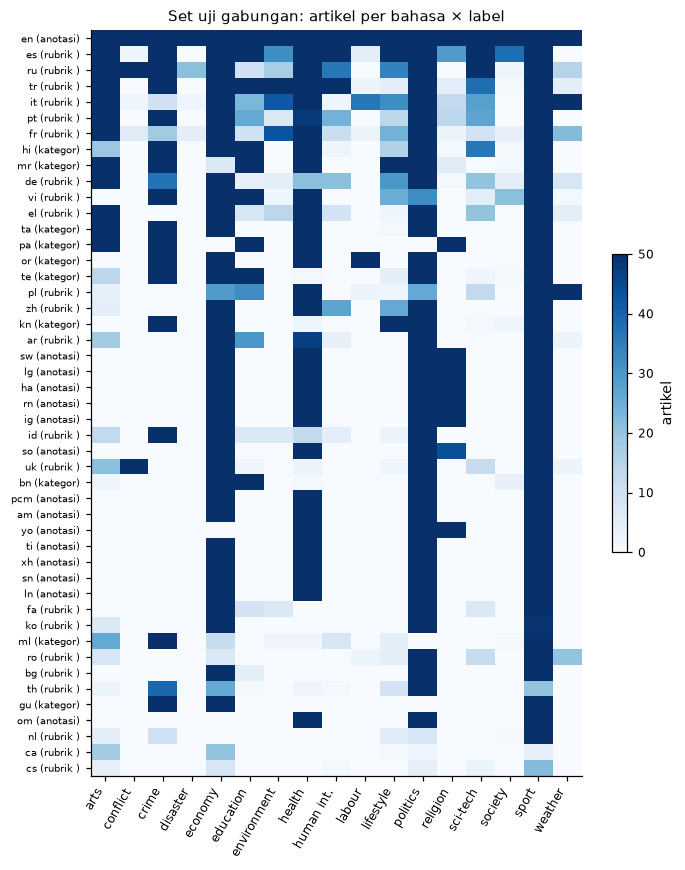

In [12]:
ct = pd.crosstab(test.lang, test.label).reindex(columns=LABELS, fill_value=0)
ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).index]
fig, ax = plt.subplots(figsize=(7.2, 8.8))
im = ax.imshow(ct.values, cmap="Blues", aspect="auto", vmin=0, vmax=50)
ax.set_xticks(range(NUM_LABELS)); ax.set_xticklabels(SHORT_LABELS, rotation=60, ha="right")
ax.set_yticks(range(len(ct))); ax.set_yticklabels([f"{l} ({an.ORIGIN_NAMES[test[test.lang == l].label_origin.mode()[0]][:7]})" for l in ct.index], fontsize=6.5)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.4, label="artikel")
ax.set_title("Set uji gabungan: artikel per bahasa × label")
viz.show_and_save(fig, "fig_testset_heatmap")
label_counts = test.label.value_counts().reindex(LABELS)
NUM.add("ts.label.max", int(label_counts.max()), 0); NUM.add("ts.label.min", int(label_counts.min()), 0)
NUM.add("ts.label.min.name", SHORT_LABELS[LABELS.index(label_counts.idxmin())])

<a id="4"></a>
## 4. Teacher

*Teacher* adalah pengklasifikasi IPTC multibahasa terbuka dari Kuzman & Ljubešić (2025),
`classla/multilingual-IPTC-news-topic-classifier`. Model ini adalah XLM-RoBERTa-large yang di-*fine-tune*
pada 15.000 artikel EMMediaTopic berlabel GPT-4o (ca, el, hr, sl). Menurut paper aslinya, macro-F1 model
ini pada test set manusia adalah 0,746. Input dipotong ke 512 token.

### 4.1 Profil teacher

In [13]:
from huggingface_hub import snapshot_download
from safetensors import safe_open
teacher_dir = Path(snapshot_download(config.TEACHER_MODEL_ID))
with safe_open(str(teacher_dir / "model.safetensors"), "np") as f:
    teacher_params = sum(int(np.prod(f.get_slice(k).get_shape())) for k in f.keys())
teacher_cfg = json.loads((teacher_dir / "config.json").read_text())
teacher_profile = pd.Series({
    "arsitektur": teacher_cfg["architectures"][0], "layer": teacher_cfg["num_hidden_layers"],
    "hidden": teacher_cfg["hidden_size"], "parameter (juta)": round(teacher_params / 1e6, 1),
    "ukuran file (MB)": round((teacher_dir / "model.safetensors").stat().st_size / 2**20, 0),
    "vocab": teacher_cfg["vocab_size"], "maks. token": 512})
NUM.add("teacher.params", teacher_params / 1e6, 1)
NUM.add("teacher.layers", teacher_cfg["num_hidden_layers"], 0)
teacher_profile.to_frame("teacher")

,teacher
arsitektur,XLMRobertaForSequenceClassification
layer,24
hidden,1024
parameter (juta),559.9000
ukuran file (MB),2136.0000
vocab,250002
maks. token,512


### 4.2 Pelabelan distilasi (*soft label*)

Untuk setiap dokumen $d$ di korpus distilasi, *teacher* menghasilkan vektor logit
$\mathbf{z}^{T}(d)\in\mathbb{R}^{17}$ yang disimpan utuh, bukan hanya label argmax-nya. Distribusi lengkap
ini adalah inti *knowledge distillation* (Hinton dkk.): probabilitas kelas selain kelas pemenang
membawa informasi kemiripan antarkelas, misalnya artikel tentang anggaran kesehatan yang dekat dengan
*economy* dan *politics*.

Pelabelan dijalankan sekali secara *offline* dalam fp16 di GPU. Batch diurutkan menurut panjang teks agar
*padding* minimal. GPU hanya mempercepat proses; logitnya tidak bergantung pada perangkat.

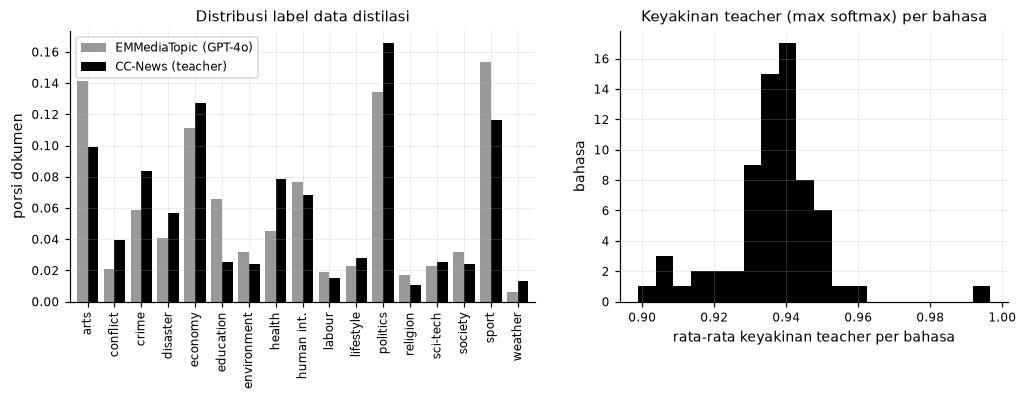

In [14]:
if RUN_TEACHER_LABELS:
    run_script("label_with_teacher.py", "--corpora", "emmediatopic", "ccnews_train", "ccnews_heldout", "ccnews_train_extra")

teacher_p = data.teacher_probs(pool)
pool_t = pool.assign(teacher_label=teacher_p.argmax(1), teacher_conf=teacher_p.max(1))
dist = pd.DataFrame({
    "EMMediaTopic (GPT-4o)": emm[emm.split == "train"].label_id.value_counts(normalize=True).reindex(range(NUM_LABELS), fill_value=0).values,
    "CC-News (teacher)": pool_t[pool_t.source != "emmediatopic"].teacher_label.value_counts(normalize=True).reindex(range(NUM_LABELS), fill_value=0).values,
}, index=SHORT_LABELS)
conf_lang = pool_t[pool_t.source != "emmediatopic"].groupby("lang").teacher_conf.mean()
NUM.add("teacher.conf.min", conf_lang.min(), 2); NUM.add("teacher.conf.max", conf_lang.max(), 2)
for lab in ("politics", "economy, business and finance", "sport", "weather"):
    NUM.add(f"teacher.share.{SHORT_LABELS[LABELS.index(lab)]}", dist.loc[SHORT_LABELS[LABELS.index(lab)], "CC-News (teacher)"], 1, percent=True)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), gridspec_kw={"width_ratios": [1.2, 1]})
dist.plot.bar(ax=axes[0], color=["#999999", viz.COLORS["teacher"]], width=0.8)
axes[0].set_ylabel("porsi dokumen"); axes[0].set_title("Distribusi label data distilasi")
axes[1].hist(conf_lang.values, bins=20, color=viz.COLORS["teacher"])
axes[1].set_xlabel("rata-rata keyakinan teacher per bahasa"); axes[1].set_ylabel("bahasa")
axes[1].set_title("Keyakinan teacher (max softmax) per bahasa")
viz.show_and_save(fig, "fig_teacher_labels")

<a id="5"></a>
## 5. Metode StaticKD langkah demi langkah

StaticKD mengubah *teacher* 560 juta parameter menjadi **satu tabel berisi 17 angka per token**.
Rumusnya:

$$
\mathbf{h}(d)=\frac{1}{n}\sum_{i=1}^{n}\mathbf{e}_{t_i},\qquad
\mathbf{z}^{S}(d)=W\,\mathbf{h}(d)+\mathbf{b}
\;\;\Longrightarrow\;\;
\mathbf{z}^{S}(d)=\frac{1}{n}\sum_{i=1}^{n}T_{t_i}+\mathbf{b},\quad T=EW^{\top}
$$

dengan $t_1,\dots,t_n$ token dokumen, $E\in\mathbb{R}^{|V|\times 256}$ matriks embedding statis,
$W\in\mathbb{R}^{17\times 256}$ kepala linear, dan $T\in\mathbb{R}^{|V|\times 17}$ tabel hasil pelipatan.
Sub-bagian berikut membahas setiap komponen, masing-masing dengan contoh kecil yang bisa diperiksa.

### 5.1 Tokenisasi

Tokenizer Unigram milik `potion-multilingual-128M` (500.353 token) memecah teks dari bahasa apa pun
menjadi potongan subword. Token khusus tidak dipakai, token tidak dikenal dibuang, dan maksimal 1.024
token dipakai per dokumen. Artikel 512 kata jarang melebihi batas ini, dan biayanya linear.

In [15]:
from statickd import student as st
tokenizer, E = st.load_base_embeddings()
examples = {
    "id": "Bank Indonesia menaikkan suku bunga acuan untuk menahan inflasi.",
    "en": "The central bank raised its benchmark interest rate to curb inflation.",
    "sw": "Benki kuu imepandisha kiwango cha riba ili kudhibiti mfumuko wa bei.",
    "hi": "केंद्रीय बैंक ने महंगाई रोकने के लिए ब्याज दर बढ़ाई।",
}
for lang, text in examples.items():
    toks = tokenizer.encode(text, add_special_tokens=False).tokens
    print(f"{lang}: {len(toks):2d} token | {' '.join(toks[:14])}")
print(f"\nvocab = {E.shape[0]:,} token, dimensi embedding = {E.shape[1]}")
NUM.add("student.vocab", E.shape[0], 0); NUM.add("student.dim", E.shape[1], 0)

id: 11 token | ▁Bank ▁Indonesia ▁menaikkan ▁suku ▁bunga ▁acuan ▁untuk ▁menahan ▁inflasi ▁ .
en: 13 token | ▁The ▁central ▁bank ▁raised ▁its ▁benchmark ▁interest ▁rate ▁to ▁curb ▁inflation ▁ .
sw: 17 token | ▁Benki ▁kuu ▁ime pandi sha ▁kiwango ▁cha ▁riba ▁ili ▁kudhibiti ▁m fum uko ▁wa
hi: 12 token | ▁केंद्रीय ▁बैंक ▁ने ▁महंगाई ▁रोकने ▁के ▁लिए ▁ब्याज ▁दर ▁बढ़ ाई ।

vocab = 500,353 token, dimensi embedding = 256


### 5.2 Embedding statis yang selaras lintas bahasa

$E$ diinisialisasi dari `potion-multilingual-128M` (Model2Vec). Embedding ini adalah embedding token
statis yang didistilasi dari *sentence encoder* BGE-M3 untuk 101 bahasa. Karena gurunya multibahasa,
kalimat yang maknanya sama dalam bahasa berbeda mendapat rata-rata embedding yang berdekatan. Sifat inilah
yang memungkinkan transfer ke bahasa yang sedikit atau tidak punya data distilasi. Contoh di bawah
menghitung *cosine similarity* rata-rata embedding antara kalimat "suku bunga" di empat bahasa dan kalimat
olahraga.

In [16]:
def doc_vector(text):
    ids = st.encode(tokenizer, [text])[0]
    return E[ids].mean(axis=0)

sport = {"id-sport": "Tim nasional menang 2-1 di final piala dunia.", "en-sport": "The national team won the World Cup final 2-1."}
vecs = {k: doc_vector(v) for k, v in {**examples, **sport}.items()}
names = list(vecs)
M = np.array([[np.dot(vecs[a], vecs[b]) / np.linalg.norm(vecs[a]) / np.linalg.norm(vecs[b]) for b in names] for a in names])
pd.DataFrame(M, index=names, columns=names).round(2)

,id,en,sw,hi,id-sport,en-sport
id,1.0000,0.7200,0.3400,0.6200,0.0300,0.0300
en,0.7200,1.0000,0.4300,0.6700,0.0400,0.0400
sw,0.3400,0.4300,1.0000,0.4400,0.0300,-0.0600
hi,0.6200,0.6700,0.4400,1.0000,-0.0800,-0.0600
id-sport,0.0300,0.0400,0.0300,-0.0800,1.0000,0.7300
en-sport,0.0300,0.0400,-0.0600,-0.0600,0.7300,1.0000


Kalimat ekonomi dalam empat bahasa saling mirip (nilai tinggi), dan lebih mirip satu sama lain daripada
dengan kalimat olahraga dalam bahasa yang sama. Ini adalah transfer lintas bahasa yang tidak dimiliki
fastText, karena embedding fastText dilatih dari nol per token.

### 5.3 Target distilasi dan *temperature*

*Student* dilatih meminimalkan divergensi Kullback–Leibler terhadap distribusi *teacher* yang dilunakkan
dengan *temperature* $\tau$:

$$\mathcal{L}_{\mathrm{KD}}=\tau^{2}\,\mathrm{KL}\!\left(\mathrm{softmax}(\mathbf{z}^{T}/\tau)\,\middle\|\,\mathrm{softmax}(\mathbf{z}^{S}/\tau)\right)$$

Faktor $\tau^2$ menjaga skala gradien. $\tau$ besar membuat distribusi lebih rata, sehingga *student*
dipaksa meniru "ekor" distribusi. $\tau=1$ memakai distribusi asli *teacher*. Hasil ablasi (Bagian 9)
menunjukkan $\tau=1$ lebih baik untuk *student* berkapasitas sangat rendah ini. Contoh satu artikel:

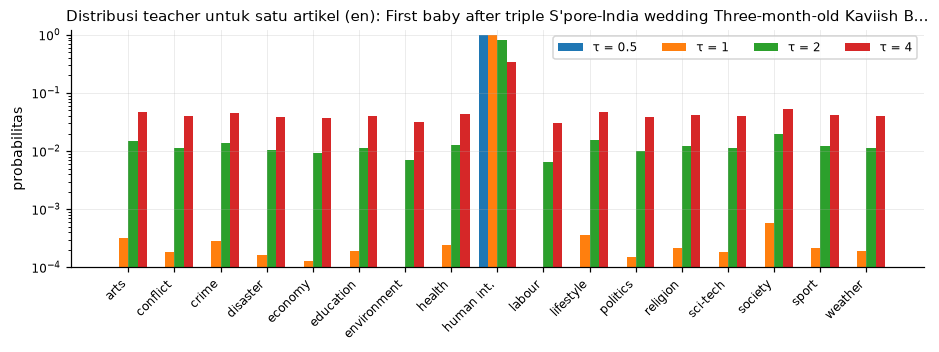

In [17]:
row = pool[(pool.source == "ccnews") & (pool.lang == "en")].iloc[40]
z = np.asarray(row.teacher_logits)
fig, ax = plt.subplots(figsize=(10, 2.8))
for k, tau in enumerate([0.5, 1, 2, 4]):
    ax.bar(np.arange(NUM_LABELS) + (k - 1.5) * 0.2, data.softmax(z, tau), width=0.2, label=f"τ = {tau}")
ax.set_xticks(range(NUM_LABELS)); ax.set_xticklabels(SHORT_LABELS, rotation=45, ha="right")
ax.set_ylabel("probabilitas"); ax.legend(ncol=4); ax.set_yscale("log"); ax.set_ylim(1e-4, 1.2)
ax.set_title(f"Distribusi teacher untuk satu artikel ({row.lang}): {row.text[:70]}...")
viz.show_and_save(fig, "fig_temperature_example")

### 5.4 Implementasi training

Fungsi `statickd.student.train` mengimplementasikan langkah-langkah berikut. Kode aslinya ditampilkan di
bawah, sehingga yang dibaca di notebook sama dengan yang dijalankan.

1. **Data.** Muat 285.999 dokumen distilasi beserta logit *teacher*, tokenisasi (dengan *cache*), dan
   hitung $p^T=\mathrm{softmax}(\mathbf{z}^T/\tau)$.
2. **Split.** Sisihkan 3% dokumen acak sebagai validasi internal. Metriknya kesepakatan argmax dengan
   *teacher*, dipakai untuk memilih *epoch* terbaik.
3. **Model.**
   - `EmbeddingBag(mode="mean")` diinisialisasi dari potion. Ini menghitung $\mathbf{h}(d)$ langsung dari
     token id tanpa matriks padat.
   - Kepala: *dropout* 0,1 pada $\mathbf{h}$, lalu `Linear(256, 17)`.
4. **Optimasi.**
   - Embedding memakai **SparseAdam** ($\eta=10^{-3}$): hanya baris token yang muncul di *batch* yang
     diperbarui. Ini penting, karena 500 ribu baris × 256 dimensi terlalu mahal jika diperbarui padat.
   - Kepala memakai AdamW ($\eta=3\cdot10^{-3}$, *weight decay* $10^{-4}$).
   - *Batch* 64 dokumen, 6 *epoch*.
5. **Token dropout.** Setiap token dokumen latih dibuang dengan probabilitas 0,2 pada setiap langkah. Ini
   augmentasi murah agar model tidak bergantung pada beberapa kata kunci.
6. **Simpan.** Bobot dari *epoch* dengan kesepakatan validasi tertinggi dilipat menjadi tabel $T$.

In [18]:
import inspect, re
from IPython.display import Code

def show_code(obj, start=None, end=None):
    # Display the real source of `obj` (optionally between two marker strings).
    src = inspect.getsource(obj)
    if start:
        src = src[src.index(start):]
    if end:
        src = src[:src.index(end) + len(end)]
    display(Code(src, language="python"))

show_code(st.train, "    def forward(idx, augment=False):", "            total += loss.item()")

def forward(idx, augment=False):
        seqs = [ids[i] for i in idx]
        if augment and cfg.token_dropout > 0:
            seqs = drop_tokens(seqs, seqs)
        flat, off = pack(seqs)
        if tok_w is None:
            pooled = emb(flat, off)
        else:
            w = tok_w[flat]
            lengths = torch.diff(off, append=torch.tensor([len(flat)], device=device))
            bag = torch.repeat_interleave(torch.arange(len(off), device=device), lengths)
            denom = torch.zeros(len(off), device=device).index_add_(0, bag, w)
            pooled = emb(flat, off, per_sample_weights=w) / denom[:, None]
        logits = head(pooled)
        if bigram is not None:
            bseqs = [bids[i] for i in idx]
            if augment and cfg.token_dropout > 0:
                bseqs = [s[rng.random(len(s)) >= cfg.token_dropout] if len(s) > 4 else s for s in bseqs]
            logits = logits + bigram(*pack(bseqs))
        return logits

    def val_agreement():
        emb.eval(), head.eval()
        preds = []
        with torch.no_grad():
            for s in range(0, len(val_idx), 1024):
                preds.append(forward(val_idx[s:s + 1024]).argmax(-1).cpu().numpy())
        emb.train(), head.train()
        return float((np.concatenate(preds) == hard[val_idx]).mean())

    history, best, best_state = [], -1.0, None
    steps = len(train_idx) // cfg.batch_size
    t0 = time.perf_counter()
    for epoch in range(cfg.epochs):
        rng.shuffle(train_idx)
        total = 0.0
        for step in range(steps):
            idx = train_idx[step * cfg.batch_size:(step + 1) * cfg.batch_size]
            logits = forward(idx, augment=True)
            w = torch.from_numpy(sample_w[idx]).to(device)
            if cfg.loss == "kd":
                target = torch.from_numpy(probs[idx]).to(device)
                per_doc = F.kl_div(F.log_softmax(logits / cfg.temperature, -1), target, reduction="none").sum(-1)
                loss = (w * per_doc).mean() * cfg.temperature ** 2
            else:
                loss = (w * F.cross_entropy(logits, torch.from_numpy(hard[idx]).to(device), reduction="none")).mean()
            if cfg.gpt_weight > 0:
                y = torch.from_numpy(gpt[idx]).to(device)
                if (y >= 0).any():
                    loss = loss + cfg.gpt_weight * F.cross_entropy(logits[y >= 0], y[y >= 0])
            for opt in optimisers:
                opt.zero_grad()
            loss.backward()
            for opt in optimisers:
                opt.step()
            total += loss.item()

### 5.5 Pelipatan kepala linear ke tabel token

Kepala linear dan rata-rata dapat dipertukarkan:
$W\big(\tfrac{1}{n}\sum_i \mathbf{e}_{t_i}\big) = \tfrac{1}{n}\sum_i (W\mathbf{e}_{t_i})$. Karena itu
$T=EW^\top$ dihitung sekali setelah *training*. Inferensi hanya berupa pengambilan baris tabel,
rata-rata, dan penambahan bias, tanpa perkalian matriks dan tanpa PyTorch. Tabel 500.353 × 17 dalam fp16
berukuran 17 MB. Sel berikut memeriksa kesetaraan ini secara numerik dengan kepala acak.

In [19]:
rng = np.random.default_rng(0)
W, b = rng.normal(0, 0.1, (NUM_LABELS, E.shape[1])).astype(np.float32), rng.normal(0, 0.1, NUM_LABELS).astype(np.float32)
T = E @ W.T
ids = st.encode(tokenizer, [examples["id"]])[0]
unfolded = W @ E[ids].mean(axis=0) + b      # training form: pool the 256-d embeddings, then the head
folded = T[ids].mean(axis=0) + b            # deployment form: pool 17-d table rows
print("max |selisih| =", float(np.abs(unfolded - folded).max()))
print(f"ukuran tabel: {T.shape[0]:,} x {T.shape[1]} = {T.astype(np.float16).nbytes / 2**20:.1f} MB (fp16) "
      f"vs embedding {E.nbytes / 2**20:.0f} MB (fp32)")

max |selisih| = 2.384185791015625e-07
ukuran tabel: 500,353 x 17 = 16.2 MB (fp16) vs embedding 489 MB (fp32)


### 5.6 *Ensemble* tanpa biaya inferensi

*Student* bersifat linear terhadap tabelnya. Rata-rata logit $K$ model dengan *seed* berbeda,
$\frac{1}{K}\sum_k\big(\frac{1}{n}\sum_i T^{(k)}_{t_i}+\mathbf{b}^{(k)}\big)$, sama dengan logit **satu**
model yang tabelnya $\bar T=\frac{1}{K}\sum_k T^{(k)}$ dan biasnya $\bar{\mathbf{b}}$. Jadi *ensemble*
disimpan sebagai satu tabel dengan ukuran dan kecepatan yang sama. StaticKD final adalah rata-rata tabel
tiga *seed* (0, 1, 2) dari resep final. Resep ini ditetapkan dari set *development* sebelum set uji
gabungan dibangun. Pemeriksaannya dilakukan di Bagian 6 setelah model dilatih.

### 5.7 Varian *compact*

Struktur internal tokenizer Unigram 500 ribu token memakan sekitar 490 MB RAM, sedangkan tabelnya hanya
17 MB. Varian *compact* membuang potongan token yang muncul kurang dari 10 kali di korpus distilasi
(karakter tunggal tetap dipertahankan). Kata langka lalu dipecah menjadi potongan yang lebih pendek oleh
algoritma Viterbi Unigram.

<a id="6"></a>
## 6. Training StaticKD dan baseline

### 6.1 Daftar run

Semua run StaticKD didefinisikan di `statickd.experiments.ABLATIONS`. Setiap varian mengubah **satu
faktor** terhadap resep final, dan setiap konfigurasi diulang dengan beberapa *seed* supaya perbedaannya
bisa diuji secara statistik:
- resep final: 10 *seed*;
- ablasi dan *temperature*: 5 *seed*;
- varian hasil negatif: 3 *seed*.

Dengan GPU RTX 4050, satu run membutuhkan sekitar 3–7 menit.

In [20]:
from statickd import experiments as ex
registry = pd.DataFrame([{"kode": k, "varian": d, "perubahan": ", ".join(f"{a}={b}" for a, b in o.items()) or "-",
                          "seed": len(s)} for k, (d, o, s) in ex.ABLATIONS.items()])
NUM.add("runs.total", len(ex.all_runs()), 0)
show(registry, "Registry run StaticKD", digits=0)
import inspect as _inspect
from statickd import baselines as bl, transformer_student as ts_mod
cfg = ex.StaticKDConfig(name="final"); tcfg = ts_mod.TransformerKDConfig(name="x")
ft_def = {k: v.default for k, v in _inspect.signature(bl.train_fasttext).parameters.items() if v.default is not _inspect.Parameter.empty}
tf_def = {k: v.default for k, v in _inspect.signature(bl.train_tfidf).parameters.items() if v.default is not _inspect.Parameter.empty}
def sci(x):
    e = int(np.floor(np.log10(x))); m = x / 10 ** e
    return f"$10^{{{e}}}$" if abs(m - 1) < 1e-9 else rf"${fmt(m, 0)}\cdot 10^{{{e}}}$"
SEC = lambda title: (rf"\multicolumn{{2}}{{@{{}}l}}{{\textit{{{title}}}}} \\", None)
hp = [SEC("StaticKD"),
      (r"\quad embedding awal", rf"potion-multilingual-128M ({fmt(E.shape[0], 0)} $\times$ {E.shape[1]})"),
      (r"\quad maks. token / \eng{dropout} vektor", f"1.024 / {fmt(cfg.dropout, 1)}"),
      (r"\quad \eng{loss}, $\tau$", rf"KL, $\tau={fmt(cfg.temperature, 0)}$"),
      (r"\quad \eng{token dropout}", fmt(cfg.token_dropout, 1)),
      (r"\quad optimizer embedding / kepala", rf"SparseAdam {sci(cfg.lr_emb)} / AdamW {sci(cfg.lr_head)}, wd $10^{{-4}}$"),
      (r"\quad \eng{batch}, \eng{epoch}, validasi", rf"{cfg.batch_size}, {cfg.epochs}, {fmt(cfg.val_fraction, 0, percent=True)} data (pilih \eng{{epoch}})"),
      (r"\quad \eng{ensemble}", rf"rata-rata tabel {len(ex.V2_MEMBERS)} \eng{{seed}}"),
      SEC("fastText"),
      (r"\quad dim, lr, \eng{epoch}, n-gram kata", rf"{ft_def['dim']}, {fmt(ft_def['lr'], 1)}, {ft_def['epoch']} (25 untuk label GPT-4o), {ft_def['word_ngrams']}; \eng{{softmax}}, 2 jt \eng{{bucket}}"),
      (r"\quad token", "kata (+ n-gram karakter 2--5) atau subword XLM-R"),
      (r"\quad kuantisasi", r"\texttt{quantize}, \eng{cutoff} 300 rb, \eng{retrain}"),
      SEC("TF-IDF + SVM"),
      (r"\quad fitur", rf"subword XLM-R uni+bigram, min.\ df 3, maks.\ {fmt(tf_def['max_features'], 0)}, \eng{{sublinear tf}}"),
      (r"\quad klasifikator", f"LinearSVC, $C={fmt(tf_def['c'], 1)}$"),
      SEC("MiniLM-L6 / DistilmBERT + KD"),
      (r"\quad optimizer", rf"AdamW {sci(tcfg.lr)}, wd 0,01, \eng{{warmup}} 6\%, linear, fp16"),
      (r"\quad \eng{batch}, \eng{epoch}, maks. token", f"{tcfg.batch_size}, {tcfg.epochs}, {tcfg.max_length}"),
      (r"\quad $\tau$", r"$\{1, 2\}$, dipilih pada dev")]
write_table("hparams", [a if b is None else rf"{a} & {b} \\" for a, b in hp])
show(pd.Series(ex.StaticKDConfig(name="final").__dict__).drop(["extra", "name"]).astype(str).to_frame("nilai"),
     "Hiperparameter resep final")

**Registry run StaticKD**

,kode,varian,perubahan,seed
0,full,Resep final (satu seed),-,10
1,hard,"Label keras teacher (arg-max, cross-entropy) alih-alih soft label",loss=hard,5
2,emm_only,"Data distilasi hanya EMMediaTopic (4 bahasa, 20 rb dokumen)","sources=('emmediatopic',), epochs=10",5
3,data130k,Data distilasi 130 rb dokumen (tanpa CC-News tambahan),"sources=('emmediatopic', 'ccnews')",5
4,random_init,Embedding diinisialisasi acak (tanpa potion-multilingual),init=random,5
5,frozen,"Embedding potion dibekukan, hanya kepala linear dilatih",freeze_embeddings=True,5
6,no_tdrop,Tanpa token dropout,token_dropout=0.0,5
7,mlp,Kepala MLP 512 unit (tidak dapat dilipat),hidden=512,5
8,tau0.5,"Temperatur tau = 0,5",temperature=0.5,5
9,tau2,Temperatur tau = 2,temperature=2.0,5


**Hiperparameter resep final**

,nilai
sources,"('emmediatopic', 'ccnews', 'ccnews_extra')"
seed,0
init,potion
freeze_embeddings,False
hidden,0
dropout,0.1
loss,kd
temperature,1.0
token_dropout,0.2
epochs,6


run selesai: 72 | epoch terbaik (10 seed resep final): [4, 5, 3, 4, 4, 5, 2, 4, 5, 6]


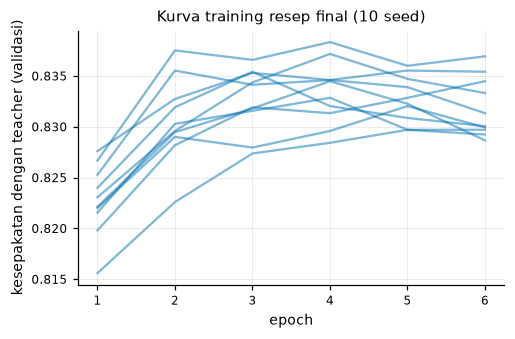

In [21]:
if RUN_TRAINING:
    run_script("train_statickd.py")   # skips runs that are already complete

seeds = an.seed_table()
meta0 = json.loads((st.STUDENTS_DIR / "full_s0" / "meta.json").read_text())
hist = pd.DataFrame([h for s in ex.MAIN_SEEDS for h in json.loads((st.STUDENTS_DIR / f"full_s{s}" / "meta.json").read_text())["history"]])
NUM.add("train.seconds", np.mean([json.loads((st.STUDENTS_DIR / f"full_s{s}" / "meta.json").read_text())["train_seconds"] for s in ex.MAIN_SEEDS]) / 60, 1)
NUM.add("train.docs", meta0["train_docs"], 0); NUM.add("train.val_docs", meta0["val_docs"], 0)
best_epochs = [int(np.argmax([h["val_agreement"] for h in json.loads((st.STUDENTS_DIR / f"full_s{s}" / "meta.json").read_text())["history"]]) + 1) for s in ex.MAIN_SEEDS]
print("run selesai:", len(seeds), "| epoch terbaik (10 seed resep final):", best_epochs)
fig, ax = plt.subplots(figsize=(5, 3))
for s, g in hist.groupby(np.repeat(ex.MAIN_SEEDS, meta0["config"]["epochs"])):
    ax.plot(g.epoch, g.val_agreement, color=viz.COLORS["statickd"], alpha=0.5)
ax.set_xlabel("epoch"); ax.set_ylabel("kesepakatan dengan teacher (validasi)")
ax.set_title("Kurva training resep final (10 seed)")
viz.show_and_save(fig, "fig_training_curves")

### 6.2 Model final: *ensemble* tabel tiga *seed* dan varian *compact*

StaticKD final adalah rata-rata tabel *seed* 0, 1, dan 2 dari resep final. Sel berikut membangun model
final, memeriksa bahwa logitnya sama dengan rata-rata logit ketiga model (Bagian 5.6), lalu membangun
varian *compact*.

In [22]:
FINAL = an.FINAL_MODELS_DIR
members = [st.STUDENTS_DIR / ex.run_name("full", s) for s in ex.V2_MEMBERS]
if not (FINAL / "statickd" / "model.npz").exists():
    st.ensemble(members, FINAL / "statickd")
if not (FINAL / "statickd_compact" / "model.npz").exists():
    st.compact(FINAL / "statickd", FINAL / "statickd_compact", min_count=10)

final_model = st.StaticKDModel(FINAL / "statickd")
sample = ev.eval_set("test")["text"].tolist()[:500]
mean_of_logits = np.mean([st.StaticKDModel(m).logits(sample) for m in members], axis=0)
diff = np.abs(final_model.logits(sample) - mean_of_logits)
same_pred = (final_model.logits(sample).argmax(1) == mean_of_logits.argmax(1)).mean()
print(f"ensemble: max |logit tabel rata-rata - rata-rata logit| = {diff.max():.4f} (pembulatan fp16), "
      f"prediksi sama: {same_pred:.3f}")
compact_model = st.StaticKDModel(FINAL / "statickd_compact")
size_table = pd.DataFrame({
    "model": ["StaticKD", "StaticKD-compact"],
    "token": [final_model.table.shape[0], compact_model.table.shape[0]],
    "parameter": [final_model.num_parameters, compact_model.num_parameters],
    "file (MB)": [final_model.size_mb, compact_model.size_mb]})
NUM.add("final.params", final_model.num_parameters / 1e6, 1); NUM.add("final.size", final_model.size_mb, 0)
NUM.add("compact.vocab", compact_model.table.shape[0], 0); NUM.add("compact.size", compact_model.size_mb, 0)
NUM.add("final.table_mb", final_model.table.nbytes / 2**20, 0)
for name, m in (("statickd", final_model), ("statickd_compact", compact_model)):
    ev.evaluate_model(name, m)
show(size_table, "Ukuran model final", digits=1)

ensemble: max |logit tabel rata-rata - rata-rata logit| = 0.0022 (pembulatan fp16), prediksi sama: 1.000


**Ukuran model final**

,model,token,parameter,file (MB)
0,StaticKD,500.353,8.506.018,"34,0"
1,StaticKD-compact,335.441,5.702.514,"23,2"


### 6.3 Baseline

Semua *baseline* memakai **data distilasi yang sama** (285.999 dokumen, 69 bahasa) dan target *teacher* yang
sama. Satu-satunya perbedaan adalah arsitektur dan jenis label (keras atau lunak).

| Baseline | Deskripsi | Label |
|---|---|---|
| fastText + KD | fastText *supervised* (dim 100, bigram kata, lr 0,5, 15 *epoch*; 25 *epoch* untuk label GPT-4o yang datanya kecil), token kata (+ n-gram karakter 2–5) atau subword XLM-R; varian terkuantisasi `.ftz` | argmax *teacher* |
| fastText, label GPT-4o | seperti Kuzman: hanya EMMediaTopic *train* (4 bahasa) | GPT-4o |
| TF-IDF + SVM + KD | TF-IDF subword XLM-R uni+bigram (maks. 1 juta fitur, *sublinear tf*) + LinearSVC (C = 0,5); versi *baseline* non-neural Kuzman yang dilatih dengan label *teacher* | argmax *teacher* |
| MiniLM-L6 + KD | mMiniLMv2-L6-H384 (didistilasi dari XLM-R-large), KD dengan *loss* yang sama, 2 *epoch*, lr 5·10⁻⁵, 256 token; τ ∈ {1, 2} dipilih di dev | *soft* |
| DistilmBERT + KD | distilbert-base-multilingual-cased, resep sama dengan MiniLM | *soft* |
| *Teacher* ONNX int8 | ekspor ONNX *dynamic int8* dari onnx-community, konfigurasi CPU tercepat untuk *teacher* | – |

In [23]:
if RUN_BASELINES:
    run_script("train_baselines.py", "--threads", "8")
if RUN_TRANSFORMERS:
    run_script("train_transformers.py")
if RUN_EVAL_TEACHER:
    run_script("evaluate_model.py", "--name", "teacher", "--spec", "teacher-gpu", "--sets", "dev", "heldout", "test")
    run_script("evaluate_model.py", "--name", "teacher_onnx_int8", "--spec", "teacher-onnx-int8", "--sets", "dev", "test",
               "--threads", "8", "--batch-size", "8")

# MiniLM: the temperature is chosen on the development set only
minilm_dev = {t: ev.macro_f1(ev.eval_view("dev").y, ev.pred_view(f"minilm_kd_t{t}", "dev"))
              for t in (1, 2) if ev.has_predictions(f"minilm_kd_t{t}", "dev")}
MINILM = f"minilm_kd_t{max(minilm_dev, key=minilm_dev.get)}" if minilm_dev else None
print("MiniLM macro-F1 dev per temperature:", {t: round(v, 4) for t, v in minilm_dev.items()}, "-> dipakai:", MINILM)
MODEL_KEYS = {"minilm_kd": MINILM}
def key(m):  # registry key -> prediction name
    return MODEL_KEYS.get(m, m)
transformer_meta = {n: json.loads((an.BASELINES_DIR / key(n) / "train_meta.json").read_text())
                    for n in ("minilm_kd", "distilmbert_kd") if key(n) and (an.BASELINES_DIR / key(n) / "train_meta.json").exists()}
for n, m in transformer_meta.items():
    print(f"{n}: τ={m['temperature']}, {m['epochs']} epoch, {m['train_seconds'] / 60:.0f} menit, "
          f"ONNX vs PyTorch (200 dok dev) = {m.get('onnx_vs_pytorch_agreement_dev200')}")

MiniLM macro-F1 dev per temperature: {1: 0.7847, 2: 0.7727} -> dipakai: minilm_kd_t1
minilm_kd: τ=1.0, 2 epoch, 40 menit, ONNX vs PyTorch (200 dok dev) = 0.995
distilmbert_kd: τ=1.0, 2 epoch, 77 menit, ONNX vs PyTorch (200 dok dev) = 1.0


<a id="7"></a>
## 7. Protokol evaluasi dan uji statistik

**Metrik.**
- **Macro-F1** atas label yang hadir di referensi (sama dengan kode evaluasi Kuzman & Ljubešić). Ini
  metrik utama karena distribusi label tidak seimbang.
- **Akurasi** (= micro-F1).
- **Macro-F1 per bahasa rata-rata** (hanya di set uji): macro-F1 dihitung di setiap bahasa atas label
  yang ada di bahasa itu, lalu dirata-rata antarbahasa. Dengan begitu bahasa besar tidak mendominasi.
- **Kesepakatan** (*fidelity*): akurasi terhadap prediksi *teacher* di CC-News *held-out*. Hanya artikel
  dari situs yang tidak pernah muncul di data distilasi (di bahasa apa pun) yang dinilai.

**Interval kepercayaan.**
- Set uji: *site-cluster bootstrap* 95% (1.000×). Yang di-*resample* adalah situs, atau dataset sumber
  bila dataset tidak memiliki URL, bukan artikel, karena artikel dari situs yang sama tidak independen.
- Dev: *bootstrap* dokumen.

**Perbandingan dua model** pada dokumen yang sama:
- *paired (cluster) bootstrap* 2.000× untuk Δmacro-F1;
- uji McNemar eksak untuk akurasi;
- koreksi Holm–Bonferroni per keluarga uji.

**Variasi antar-*seed*.** Setiap varian ablasi dibandingkan dengan resep final memakai uji Welch atas skor
per *seed* (5 vs 10 *seed*).

**Aturan.** Resep final dan semua hiperparameter ditetapkan dari set *development*. Set uji gabungan
dibangun setelah resep ditetapkan dan tidak dipakai untuk memilih apa pun.

In [24]:
show_code(ev.bootstrap_samples)
show_code(ev.paired_bootstrap)

def bootstrap_samples(n: int, clusters=None, n_boot: int = 1000, seed: int = 0):
    """Yield index arrays of bootstrap resamples. With `clusters`, whole clusters (news sites) are
    resampled with replacement, which keeps articles of the same site together (cluster bootstrap)."""
    rng = np.random.default_rng(seed)
    if clusters is None:
        for _ in range(n_boot):
            yield rng.integers(0, n, n)
        return
    groups = _cluster_index(clusters)
    for _ in range(n_boot):
        pick = rng.integers(0, len(groups), len(groups))
        yield np.concatenate([groups[g] for g in pick])

def paired_bootstrap(y, p_a, p_b, metric=macro_f1, clusters=None, n_boot: int = 2000, seed: int = 0) -> dict:
    """Difference metric(a) - metric(b) on the same documents, its 95% interval and a two-sided
    bootstrap p-value (share of resamples whose difference has the opposite sign, doubled)."""
    y, p_a, p_b = map(np.asarray, (y, p_a, p_b))
    delta = metric(y, p_a) - metric(y, p_b)
    diffs = np.array([metric(y[i], p_a[i]) - metric(y[i], p_b[i])
                      for i in bootstrap_samples(len(y), clusters, n_boot, seed)])
    p = 2 * min((diffs <= 0).mean(), (diffs >= 0).mean())
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    return {"delta": float(delta), "ci_low": float(lo), "ci_high": float(hi), "p": float(min(1.0, p))}

<a id="8"></a>
## 8. Hasil akurasi (RQ2)

### 8.1 Tabel utama

Semua model dinilai pada tiga set:
- **dev**: label GPT-4o, 4 bahasa;
- **held-out**: kesepakatan dengan *teacher*, 63 bahasa, situs tak terlihat;
- **uji gabungan**: label manusia/penerbit, 47 bahasa.

Interval kepercayaan 95% ditulis dalam kurung siku.

In [25]:
MAIN = ["teacher", "teacher_onnx_int8", "distilmbert_kd", "minilm_kd", "statickd", "statickd_compact",
        "ft_kd_subword_q", "ft_kd_subword", "ft_kd_word", "tfidf_svm_kd", "ft_gpt_subword", "ft_gpt_word"]
MAIN = [m for m in MAIN if key(m) and ev.has_predictions(key(m), "dev")]
rows = []
for m in MAIN:
    r = {"model": m, "nama": an.MODELS[m][0]}
    for s in ("dev", "heldout", "test"):
        if not ev.has_predictions(key(m), s):
            continue
        sr = an.score_row(key(m), s, n_boot=N_BOOT)
        r.update({f"{s}_macro": sr["macro_f1"], f"{s}_lo": sr["ci_low"], f"{s}_hi": sr["ci_high"], f"{s}_acc": sr["accuracy"]})
        if s == "test":
            r["test_lang_macro"] = sr["lang_macro_f1"]
    rows.append(r)
main_table = pd.DataFrame(rows).set_index("model")
T_REF = main_table.loc["teacher"]
main_table["test_vs_teacher"] = main_table["test_macro"] / T_REF["test_macro"]
main_table["dev_vs_teacher"] = main_table["dev_macro"] / T_REF["dev_macro"]
show(main_table.drop(columns=["nama"]), "Tabel utama (macro-F1, CI95, akurasi)")

**Tabel utama (macro-F1, CI95, akurasi)**

,dev_macro,dev_lo,dev_hi,dev_acc,heldout_macro,heldout_lo,heldout_hi,heldout_acc,test_macro,test_lo,test_hi,test_acc,test_lang_macro,test_vs_teacher,dev_vs_teacher
model,,,,,,,,,,,,,,,
teacher,"0,8218","0,7794","0,8511","0,8590","0,9999","0,9998","1,0000","0,9999","0,5980","0,5463","0,6430","0,6995","0,7051","1,0000","1,0000"
teacher_onnx_int8,"0,8228","0,7809","0,8521","0,8580",nan,nan,nan,nan,"0,5997","0,5475","0,6461","0,6992","0,7021","1,0028","1,0012"
distilmbert_kd,"0,7534","0,7101","0,7855","0,8010","0,7621","0,7407","0,7751","0,7994","0,5344","0,4811","0,6179","0,6230","0,6023","0,8937","0,9168"
minilm_kd,"0,7847","0,7368","0,8150","0,8200","0,7950","0,7810","0,8045","0,8250","0,5656","0,5108","0,6239","0,6670","0,6609","0,9457","0,9548"
statickd,"0,7610","0,7171","0,7921","0,8000","0,7827","0,7649","0,7941","0,8115","0,5447","0,4905","0,6052","0,6410","0,6220","0,9109","0,9260"
statickd_compact,"0,7540","0,7100","0,7860","0,7970","0,7712","0,7512","0,7841","0,8018","0,4844","0,4207","0,5970","0,5441","0,5073","0,8101","0,9175"
ft_kd_subword_q,"0,7085","0,6639","0,7391","0,7590","0,6938","0,6654","0,7127","0,7397","0,4349","0,3701","0,5562","0,5125","0,4640","0,7273","0,8621"
ft_kd_subword,"0,7274","0,6908","0,7557","0,7690","0,7027","0,6759","0,7198","0,7508","0,4452","0,3838","0,5626","0,5220","0,4729","0,7445","0,8852"
ft_kd_word,"0,7433","0,7068","0,7726","0,7890","0,7048","0,6811","0,7200","0,7531","0,4383","0,3726","0,5603","0,5105","0,4724","0,7330","0,9045"


In [26]:
# one StaticKD student (no ensemble): mean ± SD over the 10 seeds of the final recipe
full = seeds[seeds.code == "full"]
single = {c: (full[c].mean(), full[c].std(ddof=1)) for c in ["dev_macro", "dev_acc", "heldout_acc", "test_macro", "test_acc"]}
for c, (mu, sd) in single.items():
    NUM.add(f"single.{c}.mean", mu, 3); NUM.add(f"single.{c}.sd", sd, 3)
pd.DataFrame(single, index=["mean", "sd"])

,dev_macro,dev_acc,heldout_acc,test_macro,test_acc
mean,0.7547,0.7937,0.8076,0.5424,0.6397
sd,0.0103,0.0065,0.0011,0.0042,0.0040


In [27]:
for m, r in main_table.iterrows():
    for s in ("dev", "heldout", "test"):
        if f"{s}_macro" in r and pd.notna(r.get(f"{s}_macro")):
            NUM.add(f"{m}.{s}.macro", r[f"{s}_macro"]); NUM.add(f"{m}.{s}.acc", r[f"{s}_acc"])
            NUM.add(f"{m}.{s}.ci", f"{fmt(r[f'{s}_lo'])}--{fmt(r[f'{s}_hi'])}")
    if pd.notna(r.get("test_lang_macro")):
        NUM.add(f"{m}.test.langmacro", r["test_lang_macro"])
        NUM.add(f"{m}.test.pct_teacher", r["test_vs_teacher"], 1, percent=True)
        NUM.add(f"{m}.dev.pct_teacher", r["dev_vs_teacher"], 1, percent=True)

def cell(r, s, bold=False):
    if pd.isna(r.get(f"{s}_macro")):
        return "--"
    v = f"{fmt(r[f'{s}_macro'])} [{fmt(r[f'{s}_lo'])}--{fmt(r[f'{s}_hi'])}]"
    return f"\\textbf{{{v}}}" if bold else v

lines = []
for m, r in main_table.iterrows():
    b = m == "statickd"
    name = an.MODELS[m][0].replace("StaticKD (usulan)", "\\textbf{StaticKD (usulan)}")
    agree = "--" if m == "teacher" or pd.isna(r.get("heldout_acc")) else fmt(r["heldout_acc"])
    vals = [name, cell(r, "dev", b), fmt(r["dev_acc"]), agree, cell(r, "test", b), fmt(r["test_acc"]),
            fmt(r["test_lang_macro"]) if pd.notna(r.get("test_lang_macro")) else "--",
            fmt(r["test_vs_teacher"], 1, percent=True) if pd.notna(r.get("test_vs_teacher")) else "--"]
    lines.append(" & ".join(vals) + " \\\\")
    if m in ("teacher_onnx_int8", "minilm_kd", "statickd_compact", "tfidf_svm_kd"):
        lines.append("\\midrule")
write_table("main", lines[:-1] if lines[-1] == "\\midrule" else lines)

WindowsPath('D:/study/s2/kuliah/semester_2/metpen/iptc_label_class/jurnal_latex/generated/tab_main.tex')

### 8.2 Uji signifikansi berpasangan

StaticKD dibandingkan dengan setiap model lain pada dokumen yang sama. Di set uji dipakai *paired
site-cluster bootstrap*, dan di dev *paired document bootstrap*. Nilai $p$ dikoreksi Holm per set.

In [28]:
sig_rows = []
for s in ("dev", "test"):
    view = ev.eval_view(s)
    y = view.y.to_numpy(); clusters = view.cluster.to_numpy() if s == "test" else None
    p_s = ev.pred_view("statickd", s)
    block = []
    for m in [m for m in MAIN if m != "statickd" and ev.has_predictions(key(m), s)]:
        p_m = ev.pred_view(key(m), s)
        pb = ev.paired_bootstrap(y, p_s, p_m, clusters=clusters, n_boot=2 * N_BOOT)
        mc = ev.mcnemar(y, p_s, p_m)
        block.append({"set": s, "vs": m, **{f"f1_{k}": v for k, v in pb.items()}, "acc_delta": float((p_s == y).mean() - (p_m == y).mean()),
                      "only_static": mc["only_a"], "only_other": mc["only_b"], "p_mcnemar": mc["p"]})
    padj = ev.holm([b["f1_p"] for b in block]); madj = ev.holm([b["p_mcnemar"] for b in block])
    for b, p1, p2 in zip(block, padj, madj):
        b["p_boot_holm"], b["p_mcnemar_holm"] = p1, p2
    sig_rows += block
sig = pd.DataFrame(sig_rows)
for _, r in sig.iterrows():
    k = f"sig.{r['set']}.{r['vs']}"
    NUM.add(k + ".delta", r.f1_delta, 3, sign=True); NUM.add(k + ".ci", f"{fmt(r.f1_ci_low, 3, sign=True)}; {fmt(r.f1_ci_high, 3, sign=True)}")
    NUM.add(k + ".p", fmt_p(r.p_boot_holm)); NUM.add(k + ".pm", fmt_p(r.p_mcnemar_holm))
lines = []
for s in ("dev", "test"):
    part = sig[sig.set == s]
    for i, (_, r) in enumerate(part.iterrows()):
        first = f"\\multirow{{{len(part)}}}{{*}}{{{'dev' if s == 'dev' else 'uji'}}}" if i == 0 else ""
        lines.append(" & ".join([first, an.MODELS[r.vs][0], f"{fmt(r.f1_delta, 3, sign=True)} [{fmt(r.f1_ci_low, 3, sign=True)}; {fmt(r.f1_ci_high, 3, sign=True)}]",
                                 fmt_p(r.p_boot_holm), fmt(r.acc_delta, 3, sign=True), f"{r.only_static}/{r.only_other}", fmt_p(r.p_mcnemar_holm)]) + " \\\\")
    if s == "dev":
        lines.append("\\midrule")
write_table("sig", lines)
show(sig.drop(columns=["f1_p", "p_mcnemar"]), "StaticKD vs model lain (Δ = StaticKD − model)")

**StaticKD vs model lain (Δ = StaticKD − model)**

,set,vs,f1_delta,f1_ci_low,f1_ci_high,acc_delta,only_static,only_other,p_boot_holm,p_mcnemar_holm
0,dev,teacher,"-0,0608","-0,0964","-0,0283","-0,0590",45,104,"0,0090","0,0000"
1,dev,teacher_onnx_int8,"-0,0618","-0,0957","-0,0285","-0,0580",46,104,"0,0090","0,0000"
2,dev,distilmbert_kd,"0,0076","-0,0298","0,0440","-0,0010",92,93,"1,0000","1,0000"
3,dev,minilm_kd,"-0,0237","-0,0570","0,0091","-0,0200",72,92,"0,6720","0,6883"
4,dev,statickd_compact,"0,0070","0,0002","0,0156","0,0030",4,1,"0,2760","1,0000"
5,dev,ft_kd_subword_q,"0,0525","0,0189","0,0888","0,0410",80,39,"0,0210","0,0015"
6,dev,ft_kd_subword,"0,0336","-0,0049","0,0692","0,0310",71,40,"0,4000","0,0252"
7,dev,ft_kd_word,"0,0177","-0,0219","0,0521","0,0110",61,50,"1,0000","1,0000"
8,dev,tfidf_svm_kd,"0,0056","-0,0300","0,0377","0,0020",52,50,"1,0000","1,0000"
9,dev,ft_gpt_subword,"0,0963","0,0563","0,1442","0,0710",125,54,"0,0000","0,0000"


### 8.3 Menurut asal label, wilayah, keragaman situs, dan data distilasi

Set uji menggabungkan tiga asal label. Jika StaticKD hanya bagus pada salah satunya, misalnya rubrik
JSON-LD yang paling mirip data distilasi CC-News, klaim akurasinya lemah. Tabel berikut memecah skor per
subkelompok. Nilai "% teacher" adalah macro-F1 model dibagi macro-F1 *teacher* pada subkelompok yang sama.

In [29]:
import re
test = ev.eval_set("test")
test = test.join(lang_info[["region", "script", "distil_tier", "diversity_tier", "distil_docs", "xlmr"]], on="lang")
GROUP_MODELS = [m for m in ["teacher", "distilmbert_kd", "minilm_kd", "statickd", "ft_kd_subword_q", "tfidf_svm_kd", "ft_gpt_subword"]
                if key(m) and ev.has_predictions(key(m), "test")]
group_tables = {}
for col in ["label_origin", "region", "distil_tier", "diversity_tier", "script", "xlmr"]:
    g = an.subgroup_scores([key(m) for m in GROUP_MODELS], col, test)
    g["model"] = g["model"].map({key(m): m for m in GROUP_MODELS})
    wide = g.pivot(index=col, columns="model", values="macro_f1")[GROUP_MODELS]
    wide.insert(0, "n", g.groupby(col).n.first())
    wide["StaticKD % teacher"] = wide["statickd"] / wide["teacher"]
    group_tables[col] = wide
    show(wide, f"Macro-F1 menurut {col}")
for col, wide in group_tables.items():
    for grp, r in wide.iterrows():
        k = f"grp.{col}.{re.sub('[^A-Za-z]', '', str(grp))[:16]}"
        for m in GROUP_MODELS:
            NUM.add(f"{k}.{m}", r[m])
        NUM.add(f"{k}.pct", r["StaticKD % teacher"], 1, percent=True); NUM.add(f"{k}.n", int(r["n"]), 0)

**Macro-F1 menurut label_origin**

model,n,teacher,distilmbert_kd,minilm_kd,statickd,ft_kd_subword_q,tfidf_svm_kd,ft_gpt_subword,StaticKD % teacher
label_origin,,,,,,,,,
human_annotation,4.094,"0,4625","0,4362","0,4361","0,4143","0,3355","0,3934","0,0271","0,8958"
publisher_category,2.600,"0,7023","0,4980","0,6738","0,6287","0,3187","0,3298","0,0627","0,8953"
publisher_section_jsonld,6.050,"0,6514","0,6290","0,6336","0,6238","0,5789","0,6094","0,1360","0,9576"


**Macro-F1 menurut region**

model,n,teacher,distilmbert_kd,minilm_kd,statickd,ft_kd_subword_q,tfidf_svm_kd,ft_gpt_subword,StaticKD % teacher
region,,,,,,,,,
Afrika,3.044,"0,6969","0,5317","0,5760","0,5423","0,3116","0,4075","0,0853","0,7782"
Asia Selatan,2.681,"0,5750","0,4100","0,5441","0,5088","0,2464","0,2755","0,0457","0,8850"
Asia Timur/Tenggara & Timur Tengah,1.574,"0,6357","0,6202","0,6212","0,6219","0,5596","0,6293","0,0853","0,9784"
Eropa,5.445,"0,6534","0,6370","0,6377","0,6376","0,5952","0,6105","0,1356","0,9757"


**Macro-F1 menurut distil_tier**

...

model,n,teacher,distilmbert_kd,minilm_kd,statickd,ft_kd_subword_q,tfidf_svm_kd,ft_gpt_subword,StaticKD % teacher
diversity_tier,,,,,,,,,
beragam (≥10),5.225,"0,6572","0,6423","0,6427","0,6416","0,5983","0,6161","0,1344","0,9762"
satu penerbit (<3),6.204,"0,5174","0,3874","0,4752","0,4325","0,2214","0,2871","0,0454","0,8359"
sedang (3–10),1.315,"0,5586","0,5558","0,5388","0,5432","0,5026","0,5333","0,0888","0,9724"


**Macro-F1 menurut script**

model,n,teacher,distilmbert_kd,minilm_kd,statickd,ft_kd_subword_q,tfidf_svm_kd,ft_gpt_subword,StaticKD % teacher
script,,,,,,,,,
Arab,425,"0,6665","0,6773","0,6732","0,6771","0,6354","0,7258","0,0710","1,0159"
Brahmi (India),2.681,"0,5750","0,4100","0,5441","0,5088","0,2464","0,2755","0,0457","0,8850"
CJK/Thai,565,"0,6765","0,6577","0,6820","0,6491","0,5472","0,6394","0,0784","0,9595"
Ge'ez,400,"0,7192","0,1659","0,7283","0,6854","0,1540","0,0981","0,0259","0,9530"
Latin,7.432,"0,5774","0,5456","0,5445","0,5251","0,4627","0,5024","0,0880","0,9093"
Sirilik/Yunani,1.241,"0,7328","0,7038","0,7177","0,7104","0,6888","0,7224","0,2030","0,9694"


**Macro-F1 menurut xlmr**

model,n,teacher,distilmbert_kd,minilm_kd,statickd,ft_kd_subword_q,tfidf_svm_kd,ft_gpt_subword,StaticKD % teacher
xlmr,,,,,,,,,
di luar pra-latih XLM-R,1.750,"0,7186","0,5858","0,6196","0,5006","0,3169","0,4573","0,0858","0,6967"
tercakup pra-latih XLM-R,10.994,"0,6087","0,5488","0,5850","0,5760","0,4678","0,5032","0,0963","0,9463"


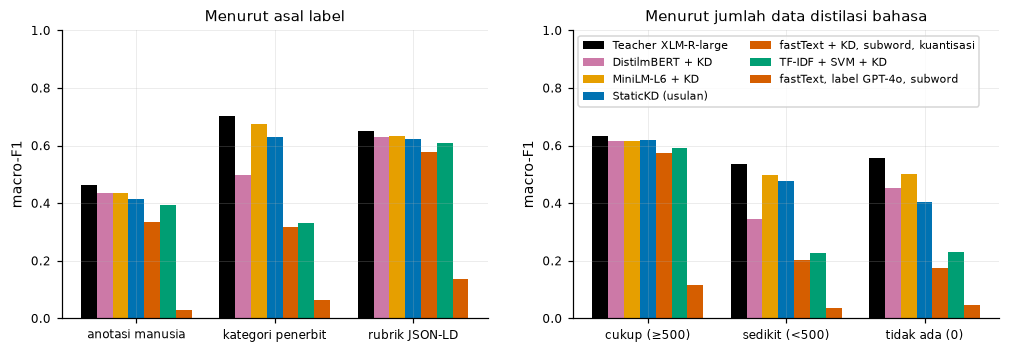

In [30]:
lines = []
order = [("label_origin", an.ORIGIN_NAMES), ("distil_tier", None), ("region", None), ("xlmr", None), ("diversity_tier", None)]
titles = {"label_origin": "Asal label", "distil_tier": "Data distilasi bahasa", "region": "Wilayah", "xlmr": "Cakupan pra-latih teacher", "diversity_tier": "Keragaman situs"}
for col, names in order:
    wide = group_tables[col]
    lines.append(f"\\multicolumn{{{len(GROUP_MODELS) + 3}}}{{@{{}}l}}{{\\textit{{{titles[col]}}}}} \\\\")
    for grp, r in wide.iterrows():
        label = names.get(grp, grp) if names else grp
        label = (label.replace("&", r"\&").replace("≥", r"$\ge$").replace("<", r"$<$").replace("–", "--")
                 .replace("pra-latih XLM-R", r"pra-latih XLM-R"))
        lines.append(" & ".join([f"\\quad {label}", fmt(int(r['n']), 0)] + [fmt(r[m]) for m in GROUP_MODELS] + [fmt(r['StaticKD % teacher'], 0, percent=True)]) + " \\\\")
GROUP_HEAD = {"teacher": r"\eng{Teacher}", "distilmbert_kd": "DistilmBERT", "minilm_kd": "MiniLM", "statickd": r"\textbf{StaticKD}",
              "ft_kd_subword_q": "fastText (q)", "tfidf_svm_kd": "TF-IDF+SVM", "ft_gpt_subword": "fastText GPT"}
# the whole tabular is generated, so that the header always matches the model columns
head = [r"\begin{tabular}{@{}lr" + "c" * (len(GROUP_MODELS) + 1) + "@{}}", r"\toprule",
        " & ".join(["Subkelompok", "$n$"] + [GROUP_HEAD[m] for m in GROUP_MODELS] + [r"\% \eng{teacher}"]) + r" \\", r"\midrule"]
write_table("groups", head + lines + [r"\bottomrule", r"\end{tabular}"])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, col in zip(axes, ["label_origin", "distil_tier"]):
    wide = group_tables[col]
    x = np.arange(len(wide)); w = 0.8 / len(GROUP_MODELS)
    for k, m in enumerate(GROUP_MODELS):
        ax.bar(x + (k - len(GROUP_MODELS) / 2 + 0.5) * w, wide[m], w, color=viz.color(m), label=an.MODELS[m][0])
    ax.set_xticks(x); ax.set_xticklabels([an.ORIGIN_NAMES.get(i, i) for i in wide.index], fontsize=8)
    ax.set_ylabel("macro-F1"); ax.set_ylim(0, 1)
axes[0].set_title("Menurut asal label"); axes[1].set_title("Menurut jumlah data distilasi bahasa")
axes[1].legend(fontsize=7, loc="upper left", ncol=2)
viz.show_and_save(fig, "fig_groups")

### 8.4 Uji sensitivitas: batas 5 artikel per situs

Sebagai pembanding aturan sampling, skor dihitung ulang pada subset dengan maksimal 5 artikel per situs di
setiap sel bahasa × label (aturan versi awal set uji). Jika peringkat model tidak berubah, kesimpulan tidak
bergantung pada aturan sampling.

In [31]:
cap_idx = an.cap_per_site(test, 5)
sens = []
for m in GROUP_MODELS:
    y, p = test.y.to_numpy(), ev.load_pred(key(m), "test")
    sens.append({"model": m, "full_macro": ev.macro_f1(y, p), "cap5_macro": ev.macro_f1(y[cap_idx], p[cap_idx]),
                 "full_acc": (y == p).mean(), "cap5_acc": (y[cap_idx] == p[cap_idx]).mean()})
sens = pd.DataFrame(sens).set_index("model")
sens["rank_full"] = sens.full_macro.rank(ascending=False).astype(int); sens["rank_cap5"] = sens.cap5_macro.rank(ascending=False).astype(int)
NUM.add("sens.n", len(cap_idx), 0)
NUM.add("sens.rank_same", "sama" if (sens.rank_full == sens.rank_cap5).all() else "berubah")
NUM.add("sens.statickd", sens.loc["statickd", "cap5_macro"]); NUM.add("sens.teacher", sens.loc["teacher", "cap5_macro"])
show(sens, f"Sensitivitas: set uji penuh vs subset maks. 5 artikel/situs/sel ({len(cap_idx)} artikel)")

**Sensitivitas: set uji penuh vs subset maks. 5 artikel/situs/sel (8139 artikel)**

,full_macro,cap5_macro,full_acc,cap5_acc,rank_full,rank_cap5
model,,,,,,
teacher,"0,5980","0,6272","0,6995","0,7191",1,1
distilmbert_kd,"0,5344","0,5623","0,6230","0,6393",4,4
minilm_kd,"0,5656","0,6036","0,6670","0,6971",2,2
statickd,"0,5447","0,5873","0,6410","0,6801",3,3
ft_kd_subword_q,"0,4349","0,4720","0,5125","0,5402",6,6
tfidf_svm_kd,"0,4862","0,5119","0,5666","0,5797",5,5
ft_gpt_subword,"0,0863","0,1022","0,1503","0,1702",7,7


### 8.5 Validitas label silver

Pemeriksaan tidak langsung terhadap label silver (kategori penerbit dan rubrik JSON-LD):
1. **Bahasa Inggris** memiliki label manusia (MN-DS, MasakhaNEWS) sekaligus label silver (CC-NEWS JSON-LD).
   Jika label silver jauh lebih bising, akurasi *teacher* pada label silver akan jauh lebih rendah daripada
   pada label manusia untuk bahasa yang sama.
2. Akurasi *teacher* per asal label untuk seluruh bahasa.

In [32]:
t_pred = ev.load_pred("teacher", "test")
val_rows = []
for (lang, origin), g in test[test.lang.isin(["en", "fr"])].groupby(["lang", "label_origin"]):
    idx = g.index.to_numpy()
    val_rows.append({"bahasa": lang, "asal label": an.ORIGIN_NAMES[origin], "n": len(g), "label": g.label.nunique(),
                     "teacher macro-F1": ev.macro_f1(g.y, t_pred[idx]), "teacher akurasi": (g.y.to_numpy() == t_pred[idx]).mean()})
validity = pd.DataFrame(val_rows)
for _, r in validity.iterrows():
    NUM.add(f"valid.{r['bahasa']}.{r['asal label'].split()[0]}.acc", r["teacher akurasi"])
    NUM.add(f"valid.{r['bahasa']}.{r['asal label'].split()[0]}.n", int(r["n"]), 0)
show(validity, "Akurasi teacher per asal label (bahasa dengan label manusia dan silver)")

**Akurasi teacher per asal label (bahasa dengan label manusia dan silver)**

,bahasa,asal label,n,label,teacher macro-F1,teacher akurasi
0,en,anotasi manusia,850,17,"0,5655","0,5588"
1,fr,anotasi manusia,200,4,"0,6172","0,5000"
2,fr,rubrik JSON-LD,208,13,"0,6932","0,7163"


Semua sel bahasa Inggris di set uji terisi sumber berlabel manusia (MN-DS, MasakhaNEWS), karena sumber
manusia diprioritaskan saat sampling. Untuk perbandingan dalam bahasa yang sama, diambil sampel artikel
CC-NEWS berbahasa Inggris berlabel rubrik JSON-LD dari *pool* yang **tidak** masuk set uji (maksimal 50 per
label, `scripts/validity_silver.py`). Sampel itu dinilai oleh *teacher* dan StaticKD dengan cara yang sama.

In [33]:
if RUN_EVAL_TEACHER:
    run_script("validity_silver.py")
from scipy import stats as sstats
v_en = pd.read_json(data.TESTSET_DIR / "validity_en_silver.jsonl", lines=True)
en = test[test.lang == "en"]
tp_s, tp_h = ev.load_pred("teacher", "valid_en_silver"), ev.load_pred("teacher", "test")[en.index]
sp_s, sp_h = ev.load_pred("statickd", "valid_en_silver"), ev.load_pred("statickd", "test")[en.index]
per_label_valid = pd.DataFrame({
    "silver (rubrik)": pd.Series(tp_s == v_en.label_id.values).groupby(v_en.label.values).mean(),
    "manusia (MN-DS/MasakhaNEWS)": pd.Series(tp_h == en.y.values).groupby(en.label.values).mean()})
per_label_valid.index = [SHORT_LABELS[LABELS.index(i)] for i in per_label_valid.index]
wil = sstats.wilcoxon(per_label_valid.iloc[:, 0], per_label_valid.iloc[:, 1])
NUM.add("valid.en.silver.n", len(v_en), 0); NUM.add("valid.en.silver.sites", v_en.domain.nunique(), 0)
NUM.add("valid.en.silver.acc", float((tp_s == v_en.label_id).mean())); NUM.add("valid.en.silver.macro", ev.macro_f1(v_en.label_id, tp_s))
NUM.add("valid.en.human.acc", float((tp_h == en.y).mean())); NUM.add("valid.en.human.macro", ev.macro_f1(en.y, tp_h))
NUM.add("valid.en.silver.static_acc", float((sp_s == v_en.label_id).mean())); NUM.add("valid.en.human.static_acc", float((sp_h == en.y).mean()))
NUM.add("valid.en.labels_higher", int((per_label_valid.iloc[:, 0] > per_label_valid.iloc[:, 1]).sum()), 0)
NUM.add("valid.en.wilcoxon.p", fmt_p(wil.pvalue))
rho_lab = sstats.spearmanr(per_label_valid.iloc[:, 0], per_label_valid.iloc[:, 1])
NUM.add("valid.en.label_rho", rho_lab.statistic, 2); NUM.add("valid.en.label_rho.p", fmt_p(rho_lab.pvalue))
print(f"teacher, bahasa Inggris: akurasi label silver {np.mean(tp_s == v_en.label_id):.3f} ({len(v_en)} artikel, {v_en.domain.nunique()} situs) "
      f"vs label manusia {np.mean(tp_h == en.y):.3f} ({len(en)} artikel); Wilcoxon per label p={wil.pvalue:.3f}; "
      f"korelasi Spearman per label rho={rho_lab.statistic:.2f}")
show(per_label_valid, "Akurasi teacher per label, bahasa Inggris: label silver vs label manusia")

teacher, bahasa Inggris: akurasi label silver 0.646 (754 artikel, 306 situs) vs label manusia 0.559 (850 artikel); Wilcoxon per label p=0.033; korelasi Spearman per label rho=0.63


**Akurasi teacher per label, bahasa Inggris: label silver vs label manusia**

,silver (rubrik),manusia (MN-DS/MasakhaNEWS)
arts,"0,8000","0,4800"
conflict,"0,9000","0,8200"
crime,"0,8200","0,5000"
disaster,"1,0000","0,6400"
economy,"0,6200","0,7000"
education,"0,7000","0,7200"
environment,"0,5400","0,7000"
health,"0,6200","0,4600"
human int.,"0,5400","0,4000"
labour,"0,4286","0,5200"


**Pemetaan per kategori sumber.** Untuk setiap kategori asli sebuah sumber (misalnya MasakhaNEWS
*politics*), dihitung porsi artikel yang diprediksi *teacher* ke label IPTC hasil pemetaan, beserta label
alternatif yang paling sering diprediksi. Hanya bahasa yang tercakup pra-latih XLM-R yang dihitung, supaya
kegagalan bahasa tidak tercampur dengan ketidakcocokan skema. Kategori dengan kesepakatan rendah
menandakan skema sumber lebih luas daripada topik IPTC tujuannya.

In [34]:
covered = test[test.lang.map(lambda l: l in an.XLMR_LANGS)]
tp = ev.load_pred("teacher", "test")
map_rows = []
for (src, sl), g in covered.groupby(["source", "source_label"]):
    if len(g) < 40:
        continue
    pred = pd.Series([LABELS[i] for i in tp[g.index]])
    alt = pred[pred != g.label.iloc[0]].value_counts()
    map_rows.append({"sumber": src, "kategori asli": sl, "label IPTC": SHORT_LABELS[LABELS.index(g.label.iloc[0])], "n": len(g),
                     "teacher setuju": float((pred.values == g.label.values).mean()),
                     "alternatif utama": f"{SHORT_LABELS[LABELS.index(alt.index[0])]} ({alt.iloc[0] / len(g):.0%})" if len(alt) else "-"})
mapping_check = pd.DataFrame(map_rows).sort_values("teacher setuju")
for src in ["masakhanews", "mnds", "l3cube_indic", "ccnews_jsonld"]:
    sub = mapping_check[mapping_check.sumber == src]
    if len(sub):
        NUM.add(f"mapcheck.{src}.median", sub["teacher setuju"].median(), 2)
m_pol = mapping_check[(mapping_check.sumber == "masakhanews") & (mapping_check["kategori asli"] == "politics")]
if len(m_pol):
    NUM.add("mapcheck.masakha_politics", m_pol["teacher setuju"].iloc[0], 2); NUM.add("mapcheck.masakha_politics.alt", m_pol["alternatif utama"].iloc[0].replace("%", "\\%"))
show(mapping_check.head(15), "Kategori sumber dengan kesepakatan teacher terendah (bahasa tercakup XLM-R)")

**Kategori sumber dengan kesepakatan teacher terendah (bahasa tercakup XLM-R)**

,sumber,kategori asli,label IPTC,n,teacher setuju,alternatif utama
12,l3cube_indic,Cinema,arts,50,"0,2000",politics (16%)
21,l3cube_indic,Religious,religion,50,"0,2200",politics (50%)
50,mnds,society,society,50,"0,2600",crime (18%)
37,masakhanews,religion,religion,144,"0,3125",crime (19%)
49,mnds,science and technology,sci-tech,50,"0,3600",health (16%)
48,mnds,religion and belief,religion,50,"0,3600",conflict (24%)
17,l3cube_indic,Fashion,arts,50,"0,3800",human int. (30%)
19,l3cube_indic,Literature,arts,50,"0,3800",human int. (28%)
45,mnds,human interest,human int.,50,"0,4000",arts (14%)
6,ccnews_jsonld,"[""Політика""]",politics,41,"0,4390",conflict (41%)


<a id="9"></a>
## 9. Ablasi, *temperature*, dan *ensemble* (RQ3)

### 9.1 Ablasi komponen

Setiap baris mengubah satu faktor terhadap resep final (satu *seed*, tanpa *ensemble*). Skor adalah
rata-rata ± simpangan baku antar-*seed*. Nilai $p$ berasal dari uji Welch terhadap 10 *seed* resep final,
dikoreksi Holm.

In [35]:
agg = seeds.groupby("code").agg(n=("seed", "size"), **{f"{c}_{f}": (c, f) for c in ["dev_macro", "heldout_acc", "test_macro", "test_acc"] for f in ["mean", "std"]})
agg = agg.reindex([c for c in ex.ABLATIONS if c in agg.index])
agg.insert(0, "varian", [ex.ABLATIONS[c][0] for c in agg.index])
base = seeds[seeds.code == "full"]
tests = {}
for c in agg.index.drop("full"):
    other = seeds[seeds.code == c]
    tests[c] = {f"p_{metric}": ev.welch(other[metric], base[metric])["p"] for metric in ["dev_macro", "heldout_acc", "test_macro"]}
tests = pd.DataFrame(tests).T
for metric in ["dev_macro", "heldout_acc", "test_macro"]:
    tests[f"p_{metric}_holm"] = ev.holm(tests[f"p_{metric}"])
ablation = agg.join(tests)
for c, r in ablation.iterrows():
    for metric in ["dev_macro", "heldout_acc", "test_macro", "test_acc"]:
        NUM.add(f"abl.{c}.{metric}", r[f"{metric}_mean"]); NUM.add(f"abl.{c}.{metric}.sd", r[f"{metric}_std"])
        if c != "full" and metric != "test_acc":
            NUM.add(f"abl.{c}.{metric}.delta", r[f"{metric}_mean"] - ablation.loc["full", f"{metric}_mean"], 3, sign=True)
            NUM.add(f"abl.{c}.{metric}.p", fmt_p(r[f"p_{metric}_holm"]))
show(ablation, "Ablasi (rata-rata ± SD antar-seed; p Welch vs resep final, Holm)")

**Ablasi (rata-rata ± SD antar-seed; p Welch vs resep final, Holm)**

,varian,n,dev_macro_mean,dev_macro_std,heldout_acc_mean,heldout_acc_std,test_macro_mean,test_macro_std,test_acc_mean,test_acc_std,p_dev_macro,p_heldout_acc,p_test_macro,p_dev_macro_holm,p_heldout_acc_holm,p_test_macro_holm
code,,,,,,,,,,,,,,,,
full,Resep final (satu seed),10,"0,7547","0,0103","0,8076","0,0011","0,5424","0,0042","0,6397","0,0040",nan,nan,nan,nan,nan,nan
hard,"Label keras teacher (arg-max, cross-entropy) alih-alih soft label",5,"0,7491","0,0075","0,8052","0,0014","0,5472","0,0038","0,6427","0,0048","0,2598","0,0139","0,0541","1,0000","0,0695","0,4326"
emm_only,"Data distilasi hanya EMMediaTopic (4 bahasa, 20 rb dokumen)",5,"0,7234","0,0061","0,7304","0,0013","0,4911","0,0017","0,5834","0,0024","0,0000","0,0000","0,0000","0,0001","0,0000","0,0000"
data130k,Data distilasi 130 rb dokumen (tanpa CC-News tambahan),5,"0,7361","0,0086","0,7989","0,0025","0,5406","0,0023","0,6379","0,0023","0,0044","0,0008","0,3057","0,0439","0,0061","1,0000"
random_init,Embedding diinisialisasi acak (tanpa potion-multilingual),5,"0,7153","0,0046","0,7386","0,0037","0,4220","0,0062","0,4928","0,0040","0,0000","0,0000","0,0000","0,0000","0,0000","0,0000"
frozen,"Embedding potion dibekukan, hanya kepala linear dilatih",5,"0,7197","0,0010","0,7878","0,0010","0,5566","0,0021","0,6606","0,0026","0,0000","0,0000","0,0000","0,0000","0,0000","0,0000"
no_tdrop,Tanpa token dropout,5,"0,7567","0,0038","0,8082","0,0013","0,5438","0,0018","0,6397","0,0018","0,5901","0,4312","0,3987","1,0000","0,6977","1,0000"
mlp,Kepala MLP 512 unit (tidak dapat dilipat),5,"0,7624","0,0087","0,8126","0,0022","0,5514","0,0064","0,6493","0,0075","0,1612","0,0046","0,0312","1,0000","0,0274","0,2807"
tau0.5,"Temperatur tau = 0,5",5,"0,7496","0,0045","0,8068","0,0016","0,5465","0,0046","0,6419","0,0058","0,2090","0,3488","0,1402","1,0000","0,6977","0,9815"


In [36]:
ABL_TEX = {  # variant descriptions for the paper (English terms in \eng{})
    "full": r"Resep final (satu \eng{seed})",
    "hard": r"Label keras \eng{teacher} (\eng{cross-entropy})",
    "emm_only": r"Data distilasi hanya EMMediaTopic (4 bahasa, 20 rb)",
    "data130k": r"Data distilasi 130 rb (tanpa CC-News tambahan)",
    "random_init": r"Embedding diinisialisasi acak",
    "frozen": r"Embedding beku (hanya kepala linear)",
    "no_tdrop": r"Tanpa \eng{token dropout}",
    "mlp": r"Kepala MLP 512 unit (tidak dapat dilipat)",
    "tau0.5": r"$\tau=0{,}5$", "tau2": r"$\tau=2$", "tau4": r"$\tau=4$",
    "bigram": r"+ bigram \eng{hashing} $2^{21}$", "idf": r"+ \eng{pooling} berbobot idf$^{0,5}$",
    "conf": r"+ bobot dokumen = keyakinan \eng{teacher}", "gpt_ce": r"+ \eng{cross-entropy} label GPT-4o",
}

def pm(r, metric):
    return f"{fmt(r[metric + '_mean'])}$\\pm${fmt(r[metric + '_std'])}"

def star(r, metric):
    if r.name == "full":
        return ""
    p = r[f"p_{metric}_holm"]
    return "$^{*}$" if p < 0.05 else ""

groups = [("Resep final", ["full"]), ("Ablasi komponen", ["hard", "emm_only", "data130k", "random_init", "frozen", "no_tdrop", "mlp"]),
          ("Temperature", ["tau0.5", "tau2", "tau4"]), ("Hasil negatif (eksplorasi)", ["bigram", "idf", "conf", "gpt_ce"])]
lines = []
for title, codes in groups:
    lines.append(f"\\multicolumn{{6}}{{@{{}}l}}{{\\textit{{{title}}}}} \\\\")
    for c in [c for c in codes if c in ablation.index]:
        r = ablation.loc[c]
        lines.append(" & ".join([f"\\quad {ABL_TEX[c]}", str(int(r['n'])), pm(r, 'dev_macro') + star(r, 'dev_macro'),
                                 pm(r, 'heldout_acc') + star(r, 'heldout_acc'), pm(r, 'test_macro') + star(r, 'test_macro'),
                                 fmt(r['test_acc_mean'])]) + " \\\\")
write_table("ablation", lines)

WindowsPath('D:/study/s2/kuliah/semester_2/metpen/iptc_label_class/jurnal_latex/generated/tab_ablation.tex')

**Ablasi per subkelompok bahasa.** Agregat set uji dapat menyembunyikan efek yang berlawanan arah di
bahasa yang berbeda. Tabel berikut menghitung macro-F1 setiap varian (rata-rata antar-*seed*) secara
terpisah untuk bahasa dengan data distilasi cukup, sedikit, dan tidak ada.

In [37]:
ABL_GROUP_CODES = ["full", "frozen", "random_init", "emm_only", "hard", "mlp", "tau2"]
y_all, tiers = test.y.to_numpy(), test.distil_tier.to_numpy()
abl_group = {}
for c in ABL_GROUP_CODES:
    seeds_c = [s for s in ex.ABLATIONS[c][2] if ev.has_predictions(ex.run_name(c, s), "test")]
    per_seed = []
    for s in seeds_c:
        p = ev.load_pred(ex.run_name(c, s), "test")
        per_seed.append({t: ev.macro_f1(y_all[tiers == t], p[tiers == t]) for t in np.unique(tiers)} | {"dev": ev.macro_f1(ev.eval_view("dev").y, ev.pred_view(ex.run_name(c, s), "dev"))})
    abl_group[c] = pd.DataFrame(per_seed).mean()
abl_group = pd.DataFrame(abl_group).T[["dev", "cukup (≥500)", "sedikit (<500)", "tidak ada (0)"]]
for c, r in abl_group.iterrows():
    for col, k in [("dev", "dev"), ("cukup (≥500)", "cukup"), ("sedikit (<500)", "sedikit"), ("tidak ada (0)", "tidakada")]:
        NUM.add(f"ablgrp.{c}.{k}", r[col])
        if c != "full":
            NUM.add(f"ablgrp.{c}.{k}.delta", r[col] - abl_group.loc["full", col], 3, sign=True)
lines = [" & ".join([ABL_TEX[c]] + [fmt(v) for v in r.values]) + " \\\\" for c, r in abl_group.iterrows()]
write_table("ablation_groups", lines)
show(abl_group, "Macro-F1 per varian menurut data distilasi bahasa (rata-rata seed)")

**Macro-F1 per varian menurut data distilasi bahasa (rata-rata seed)**

,dev,cukup (≥500),sedikit (<500),tidak ada (0)
full,"0,7547","0,6147","0,4822","0,4030"
frozen,"0,7197","0,6074","0,5407","0,4400"
random_init,"0,7153","0,5668","0,1818","0,1609"
emm_only,"0,7234","0,5589","0,4659","0,3513"
hard,"0,7491","0,6171","0,4821","0,4103"
mlp,"0,7624","0,6130","0,4843","0,4211"
tau2,"0,7482","0,6123","0,4763","0,3628"


### 9.2 *Temperature*

*Student* ini hanya punya satu lapisan linear di atas rata-rata embedding, sehingga kapasitasnya sangat
rendah. Literatur *capacity gap* memprediksi bahwa *student* seperti ini tidak mampu meniru ekor distribusi
*teacher* yang dilunakkan. Gambar berikut menunjukkan skor tiap *seed* terhadap τ.

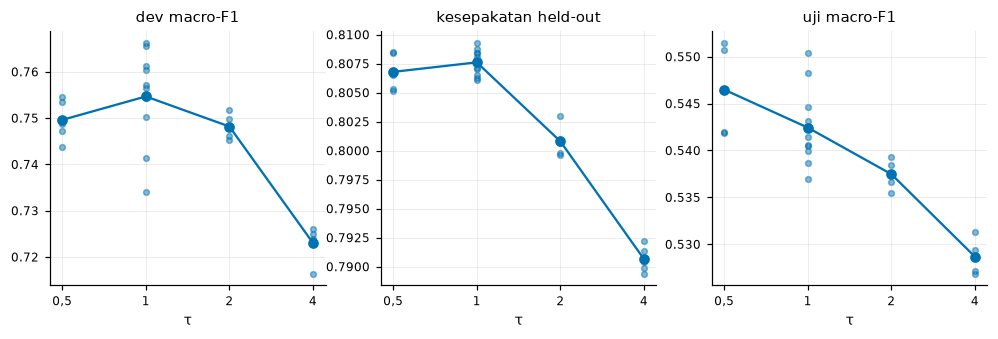

dev_macro        heldout_acc        test_macro       
            mean    std        mean    std       mean    std
tau                                                         
0.5000    0.7496 0.0045      0.8068 0.0016     0.5465 0.0046
1.0000    0.7547 0.0103      0.8076 0.0011     0.5424 0.0042
2.0000    0.7482 0.0026      0.8008 0.0014     0.5375 0.0015
4.0000    0.7230 0.0038      0.7906 0.0011     0.5287 0.0018

In [38]:
tau_codes = {"tau0.5": 0.5, "full": 1.0, "tau2": 2.0, "tau4": 4.0}
tau_df = seeds[seeds.code.isin(tau_codes)].assign(tau=lambda d: d.code.map(tau_codes))
fig, axes = plt.subplots(1, 3, figsize=(11, 3.0))
for ax, (metric, title) in zip(axes, [("dev_macro", "dev macro-F1"), ("heldout_acc", "kesepakatan held-out"), ("test_macro", "uji macro-F1")]):
    ax.scatter(tau_df.tau, tau_df[metric], color=viz.COLORS["statickd"], alpha=0.5, s=14)
    mean = tau_df.groupby("tau")[metric].mean()
    ax.plot(mean.index, mean.values, color=viz.COLORS["statickd"], marker="o")
    ax.set_xscale("log", base=2); ax.set_xticks(list(tau_codes.values())); ax.set_xticklabels(["0,5", "1", "2", "4"])
    ax.set_xlabel("τ"); ax.set_title(title)
viz.show_and_save(fig, "fig_temperature")
tau_tab = tau_df.groupby("tau")[["dev_macro", "heldout_acc", "test_macro"]].agg(["mean", "std"])
tau_tab

### 9.3 Ukuran *ensemble*

*Ensemble* $K$ *seed* dihitung dengan merata-ratakan logit tersimpan. Hasilnya setara dengan merata-ratakan
tabel, hingga pembulatan fp16. Untuk setiap $K$ diambil sampai 30 kombinasi acak dari 10 *seed* resep
final. Model final memakai $K=3$ (*seed* 0–2), yang ditetapkan sebelum set uji dibangun.

**Ukuran ensemble (rata-rata ± SD atas kombinasi seed)**

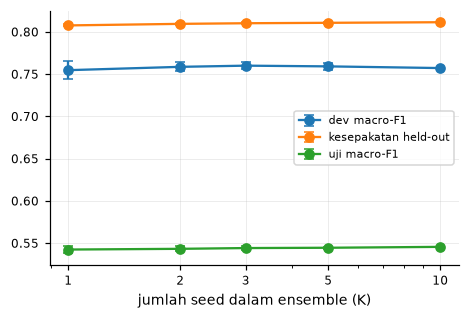

In [39]:
import itertools
rng_e = np.random.default_rng(0)
ens_rows = []
logits_cache = {(s, sn): ev.logits_view(ex.run_name("full", s), sn) for s in ex.MAIN_SEEDS for sn in ("dev", "heldout", "test")}
for k in (1, 2, 3, 5, 10):
    combos = list(itertools.combinations(ex.MAIN_SEEDS, k))
    if len(combos) > 30:
        combos = [combos[i] for i in rng_e.choice(len(combos), 30, replace=False)]
    for combo in combos:
        row = {"k": k, "seeds": combo}
        for sn in ("dev", "heldout", "test"):
            y = ev.eval_view(sn).y.to_numpy()
            pred = np.mean([logits_cache[(s, sn)] for s in combo], axis=0).argmax(1)
            row[f"{sn}_macro"], row[f"{sn}_acc"] = ev.macro_f1(y, pred), float((y == pred).mean())
        ens_rows.append(row)
ens = pd.DataFrame(ens_rows)
ens_tab = ens.groupby("k")[["dev_macro", "heldout_acc", "test_macro", "test_acc"]].agg(["mean", "std"])
for k, r in ens_tab.iterrows():
    for metric in ["dev_macro", "heldout_acc", "test_macro"]:
        NUM.add(f"ens.k{k}.{metric}", r[(metric, "mean")])
show(ens_tab, "Ukuran ensemble (rata-rata ± SD atas kombinasi seed)")
fig, ax = plt.subplots(figsize=(4.8, 3))
for metric, lab in [("dev_macro", "dev macro-F1"), ("heldout_acc", "kesepakatan held-out"), ("test_macro", "uji macro-F1")]:
    m = ens.groupby("k")[metric].mean(); s = ens.groupby("k")[metric].std().fillna(0)
    ax.errorbar(m.index, m.values, yerr=s.values, marker="o", capsize=3, label=lab)
ax.set_xscale("log"); ax.set_xticks([1, 2, 3, 5, 10]); ax.set_xticklabels([1, 2, 3, 5, 10])
ax.set_xlabel("jumlah seed dalam ensemble (K)"); ax.legend(fontsize=7)
viz.show_and_save(fig, "fig_ensemble_size")

<a id="10"></a>
## 10. Efisiensi CPU (RQ1) dan analisis generalisasi (RQ4)

### 10.1 Protokol *benchmark*

Protokol ini dirancang untuk mensimulasikan server kecil tanpa GPU (`statickd.benchmark`):
- Setiap model dijalankan di **proses baru**, dengan GPU disembunyikan. Jumlah *thread* dikunci untuk
  semua pustaka (OMP, MKL, OpenBLAS, ONNX Runtime, `tokenizers`).
- **Pinning.** Proses dipin ke *core* performa fisik (P-core). CPU Intel Core Ultra 7 155H bersifat
  *hybrid*: 6 P-core, 8 E-core yang ±2,5× lebih lambat, dan 2 LP E-core yang ±3,7× lebih lambat. Tanpa
  *pinning*, Windows memindahkan *thread* ke *core* lambat dan hasil *multi-thread* menjadi tidak stabil.
  - 1 *core*: CPU logis 0.
  - 4 *core*: CPU logis 0, 10, 12, 14.
- **Latensi** diukur dengan satu artikel per panggilan (skenario *streaming*: rata-rata, p50, p95).
  **Throughput** diukur dengan *batch* 64 (8 untuk transformer).
- **RAM model** adalah kenaikan RSS setelah model dimuat.
- **Sampel** adalah sampel acak tetap dari set uji gabungan (47 bahasa, median ±310 kata), sama untuk
  semua model.
- Semua model diukur dalam **satu sesi** saat mesin idle.

In [40]:
BENCH = [m for m in ["teacher", "teacher_onnx_int8", "distilmbert_kd", "minilm_kd", "statickd", "statickd_compact",
                     "ft_kd_subword_q", "ft_kd_subword", "tfidf_svm_kd"] if key(m)]
BENCH_FILE = FINAL_DIR / "cpu_benchmark.jsonl"

if RUN_BENCHMARK:   # all models in one session, one fresh process per (model, threads)
    run_script("run_benchmarks.py", "--minilm", key("minilm_kd"))

bench = pd.read_json(BENCH_FILE, lines=True).drop_duplicates(["model", "threads"], keep="last")
eff = bench.pivot(index="model", columns="threads", values=["latency_ms_p50", "latency_ms_p95", "docs_per_sec"])
eff.columns = [f"{a}_{b}c" for a, b in eff.columns]
eff = eff.join(bench[bench.threads == 1].set_index("model")[["rss_model_mb", "size_mb", "load_seconds", "num_parameters"]])
eff = eff.reindex([m for m in BENCH if m in eff.index])
t_onnx, t_pt = eff.loc["teacher_onnx_int8"], eff.loc["teacher"]
eff["speedup_vs_onnx"] = eff["docs_per_sec_1c"] / t_onnx["docs_per_sec_1c"]
eff["speedup_vs_pytorch"] = eff["docs_per_sec_1c"] / t_pt["docs_per_sec_1c"]
eff["cores_for_1M_per_day"] = (1e6 / 86400) / eff["docs_per_sec_1c"]
show(eff, "Efisiensi CPU (P-core terpin)", digits=2)

**Efisiensi CPU (P-core terpin)**

,latency_ms_p50_1c,latency_ms_p50_4c,latency_ms_p95_1c,latency_ms_p95_4c,docs_per_sec_1c,docs_per_sec_4c,rss_model_mb,size_mb,load_seconds,num_parameters,speedup_vs_onnx,speedup_vs_pytorch,cores_for_1M_per_day
model,,,,,,,,,,,,,
teacher,"2.970,68","982,11","3.209,95","1.749,02","0,33","0,76","2.957,00","2.135,93","11,95","559.907.857,00","0,43","1,00","34,76"
teacher_onnx_int8,"1.238,92","441,08","1.278,91","817,41","0,77","2,62","1.382,90","536,74","9,21",nan,"1,00","2,30","15,09"
distilmbert_kd,"197,92","76,61","214,85","89,17","4,88","14,60","1.068,30","516,38","6,46",nan,"6,37","14,67","2,37"
minilm_kd,"57,84","34,70","68,45","46,99","16,40","36,48","1.242,50","408,29","8,18",nan,"21,38","49,25","0,71"
statickd,"2,03","2,38","3,46","4,39","472,70","893,34","501,20","33,98","1,39","8.506.018,00","616,30","1.419,53","0,02"
statickd_compact,"1,87","1,85","3,32","3,43","549,30","1.850,87","277,00","23,18","0,81","5.702.514,00","716,17","1.649,56","0,02"
ft_kd_subword_q,"2,08","1,93","3,95","3,30","531,80","891,55","300,40","18,05","2,50",nan,"693,35","1.596,99","0,02"
ft_kd_subword,"2,26","2,07","4,30","3,46","454,76","592,46","1.120,70","838,95","2,84",nan,"592,90","1.365,64","0,03"
tfidf_svm_kd,"2,93","3,00","4,48","5,03","420,57","594,67","826,10","165,86","6,29","17.000.017,00","548,33","1.262,98","0,03"


In [41]:
for m, r in eff.iterrows():
    for c in ["latency_ms_p50_1c", "latency_ms_p95_1c", "latency_ms_p50_4c", "docs_per_sec_1c", "docs_per_sec_4c"]:
        v = r[c]
        NUM.add(f"eff.{m}.{c}", v, 2 if v < 10 else (1 if v < 100 else 0))
    NUM.add(f"eff.{m}.ram", r["rss_model_mb"], 0); NUM.add(f"eff.{m}.size", r["size_mb"], 0)
    NUM.add(f"eff.{m}.speedup_onnx", r["speedup_vs_onnx"], 0 if r["speedup_vs_onnx"] > 10 else 1)
    NUM.add(f"eff.{m}.speedup_pt", r["speedup_vs_pytorch"], 0 if r["speedup_vs_pytorch"] > 10 else 1)
    NUM.add(f"eff.{m}.cores1M", r["cores_for_1M_per_day"], 2 if r["cores_for_1M_per_day"] < 1 else 1)
NUM.add("eff.speed_vs_minilm", eff.loc["statickd", "docs_per_sec_1c"] / eff.loc["minilm_kd", "docs_per_sec_1c"], 0)
NUM.add("eff.speed_vs_distilmbert", eff.loc["statickd", "docs_per_sec_1c"] / eff.loc["distilmbert_kd", "docs_per_sec_1c"], 0)
NUM.add("eff.size_ratio_onnx", eff.loc["teacher_onnx_int8", "size_mb"] / eff.loc["statickd", "size_mb"], 0)
NUM.add("eff.size_ratio_pt", eff.loc["teacher", "size_mb"] / eff.loc["statickd", "size_mb"], 0)
DEPS = {"teacher": "torch, transformers", "teacher_onnx_int8": "onnxruntime, transformers", "distilmbert_kd": "onnxruntime, transformers",
        "minilm_kd": "onnxruntime, transformers", "statickd": "numpy, tokenizers", "statickd_compact": "numpy, tokenizers",
        "ft_kd_subword_q": "fasttext, tokenizers", "ft_kd_subword": "fasttext, tokenizers", "tfidf_svm_kd": "scikit-learn, tokenizers"}
def n(v):
    return fmt(v, 2 if v < 10 else (1 if v < 100 else 0))
lines = []
for m, r in eff.iterrows():
    name = an.MODELS[m][0].replace(" (usulan)", "")
    b = (lambda s: f"\\textbf{{{s}}}") if m == "statickd" else (lambda s: s)
    lines.append(" & ".join([b(name), b(f"{n(r.latency_ms_p50_1c)} / {n(r.latency_ms_p95_1c)}"), b(n(r.docs_per_sec_1c)), b(n(r.docs_per_sec_4c)),
                             fmt(r.rss_model_mb, 0), b(fmt(r.size_mb, 0)), DEPS[m]]) + " \\\\")
write_table("eff", lines)

WindowsPath('D:/study/s2/kuliah/semester_2/metpen/iptc_label_class/jurnal_latex/generated/tab_eff.tex')

**Rincian biaya StaticKD (1 thread): tokenisasi vs pooling tabel**

,mean_tokens,tokenize_docs_per_sec,pool_docs_per_sec,tokenize_share
model,,,,
statickd,"579,35","557,30","28.754,61","0,98"
statickd_compact,"638,27","605,51","26.518,99","0,98"


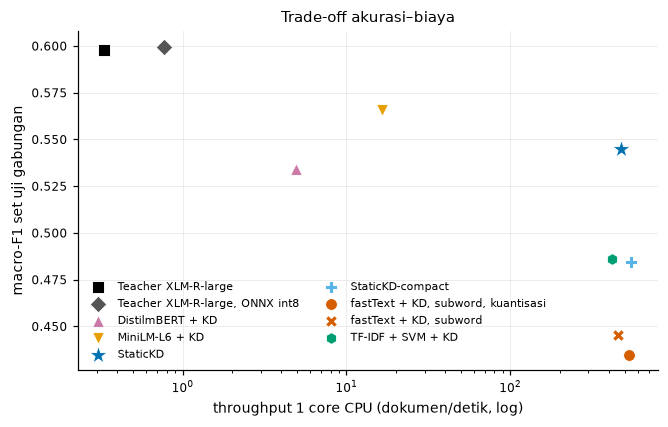

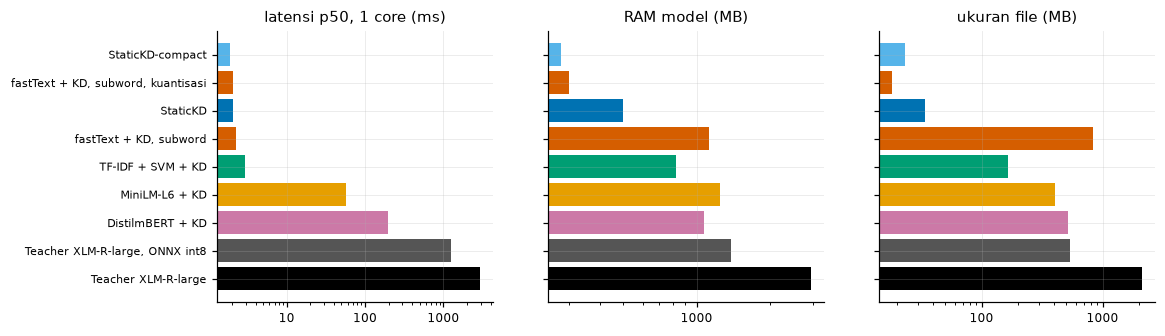

In [42]:
prof = pd.read_json(FINAL_DIR / "cpu_profile.jsonl", lines=True).drop_duplicates("model", keep="last").set_index("model")
for m, r in prof.iterrows():
    NUM.add(f"prof.{m}.tokshare", r.tokenize_share, 0, percent=True)
    NUM.add(f"prof.{m}.pool_dps", r.pool_docs_per_sec, 0); NUM.add(f"prof.{m}.tok_dps", r.tokenize_docs_per_sec, 0)
    NUM.add(f"prof.{m}.tokens", r.mean_tokens, 0)
show(prof[["mean_tokens", "tokenize_docs_per_sec", "pool_docs_per_sec", "tokenize_share"]],
     "Rincian biaya StaticKD (1 thread): tokenisasi vs pooling tabel", digits=2)

acc_col = main_table["test_macro"]
from matplotlib.ticker import NullFormatter, ScalarFormatter
MARKERS = {"teacher": "s", "teacher_onnx_int8": "D", "distilmbert_kd": "^", "minilm_kd": "v", "statickd": "*",
           "statickd_compact": "P", "ft_kd_subword_q": "o", "ft_kd_subword": "X", "tfidf_svm_kd": "h"}
fig, ax = plt.subplots(figsize=(6.8, 4.0))
for m, r in eff.iterrows():   # a legend instead of point labels: several models overlap on the log axis
    if m not in acc_col:
        continue
    ax.scatter(r.docs_per_sec_1c, acc_col[m], s=150 if m == "statickd" else 60, marker=MARKERS[m], color=viz.color(m),
               zorder=3, edgecolor="white", linewidth=0.6, label=an.MODELS[m][0].replace(" (usulan)", ""))
ax.set_xscale("log"); ax.set_xlabel("throughput 1 core CPU (dokumen/detik, log)"); ax.set_ylabel("macro-F1 set uji gabungan")
ax.legend(fontsize=7, loc="lower left", ncol=2, frameon=False)
ax.set_title("Trade-off akurasi–biaya")
viz.show_and_save(fig, "fig_tradeoff")

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
order = eff.sort_values("docs_per_sec_1c").index
for ax, col, title in zip(axes, ["latency_ms_p50_1c", "rss_model_mb", "size_mb"], ["latensi p50, 1 core (ms)", "RAM model (MB)", "ukuran file (MB)"]):
    ax.barh([an.MODELS[m][0].replace(" (usulan)", "") for m in order], eff.loc[order, col], color=[viz.color(m) for m in order])
    ax.set_xscale("log"); ax.set_title(title); ax.tick_params(axis="y", labelsize=7)
    ax.xaxis.set_major_formatter(ScalarFormatter()); ax.xaxis.set_minor_formatter(NullFormatter())
for ax in axes[1:]:
    ax.set_yticklabels([])
viz.show_and_save(fig, "fig_latency_ram_size")

### 10.2 Analisis per bahasa

Dua sumber analisis dipakai:
- **set uji** (akurasi terhadap label independen, 47 bahasa);
- **CC-News *held-out*** (kesepakatan dengan *teacher*, 63 bahasa). Set ini dipakai untuk menguji faktor
  penentu, karena jumlah dokumen per bahasanya seragam.

Faktor yang diuji:
- jumlah data distilasi (log);
- jumlah situs latih;
- keyakinan rata-rata *teacher*;
- sistem tulisan.

In [43]:
from scipy import stats as sstats
lang_rows = []
for lang, g in test.groupby("lang"):
    idx = g.index.to_numpy(); y = g.y.to_numpy()
    row = {"lang": lang, "n": len(g), "labels": g.label.nunique(), **lang_info.loc[lang, ["region", "script", "distil_tier", "diversity_tier", "distil_docs"]].to_dict()}
    for m in GROUP_MODELS:
        p = ev.load_pred(key(m), "test")[idx]
        row[f"{m}_acc"], row[f"{m}_macro"] = (y == p).mean(), ev.macro_f1(y, p)
    lang_rows.append(row)
per_lang = pd.DataFrame(lang_rows).set_index("lang")
per_lang["gap_acc"] = per_lang["statickd_acc"] - per_lang["teacher_acc"]
worst = per_lang.sort_values("gap_acc").head(8)
show(per_lang.sort_values("statickd_acc")[["n", "labels", "region", "distil_docs", "teacher_acc", "statickd_acc", "ft_kd_subword_q_acc", "gap_acc"]],
     "Akurasi per bahasa di set uji")
NUM.add("lang.static_better_ft", int((per_lang.statickd_acc > per_lang.ft_kd_subword_q_acc).sum()), 0)
NUM.add("lang.n", len(per_lang), 0)
NUM.add("lang.gap.median", per_lang.gap_acc.median(), 3, sign=True)
rho_gap = sstats.spearmanr(np.log1p(per_lang.distil_docs), per_lang.gap_acc)
NUM.add("lang.gap_vs_data.rho", rho_gap.statistic, 2); NUM.add("lang.gap_vs_data.p", fmt_p(rho_gap.pvalue))

**Akurasi per bahasa di set uji**

,n,labels,region,distil_docs,teacher_acc,statickd_acc,ft_kd_subword_q_acc,gap_acc
lang,,,,,,,,
lg,250,5,Afrika,0,"0,4760","0,1200","0,1400","-0,3560"
om,150,3,Afrika,0,"0,4467","0,1800","0,2000","-0,2667"
rn,250,5,Afrika,0,"0,6640","0,2600","0,2440","-0,4040"
xh,200,4,Afrika,0,"0,5000","0,2800","0,0500","-0,2200"
sn,200,4,Afrika,0,"0,6600","0,3000","0,2700","-0,3600"
ig,250,5,Afrika,0,"0,6880","0,3880","0,2240","-0,3000"
ln,200,4,Afrika,0,"0,6800","0,4300","0,4450","-0,2500"
so,244,5,Afrika,195,"0,4262","0,4426","0,2992","0,0164"
yo,200,4,Afrika,0,"0,6400","0,4450","0,0600","-0,1950"


**Cakupan token.** Embedding sebuah token hanya diperbarui saat *training* jika token itu muncul di data
distilasi. Token lain tetap memakai embedding awal potion. Untuk setiap bahasa uji dihitung porsi
kemunculan token yang muncul minimal 10 kali di korpus distilasi. Pertanyaannya: apakah bahasa dengan
cakupan rendah tetap bisa diklasifikasikan berkat embedding awal yang selaras lintas bahasa, atau justru
gagal?

In [44]:
counts = st.token_counts(len(E))
seen = counts >= 10
cov = {}
for lang, g in test.groupby("lang"):
    ids = st.encode(tokenizer, g.text.tolist())
    cov[lang] = float(np.mean(np.concatenate([seen[i] for i in ids])))
per_lang["token_coverage"] = pd.Series(cov)
per_lang["xlmr"] = lang_info["xlmr"]
rho_cov = sstats.spearmanr(per_lang.token_coverage, per_lang.statickd_acc)
rho_cov_gap = sstats.spearmanr(per_lang.token_coverage, per_lang.gap_acc)
NUM.add("lang.cov_vs_acc.rho", rho_cov.statistic, 2); NUM.add("lang.cov_vs_acc.p", fmt_p(rho_cov.pvalue))
NUM.add("lang.cov_vs_gap.rho", rho_cov_gap.statistic, 2); NUM.add("lang.cov_vs_gap.p", fmt_p(rho_cov_gap.pvalue))
low = per_lang[per_lang.token_coverage < 0.9]
NUM.add("lang.lowcov.langs", ", ".join(sorted(low.index))); NUM.add("lang.lowcov.n", len(low), 0)
NUM.add("lang.lowcov.acc", low.statickd_acc.mean()); NUM.add("lang.lowcov.teacher_acc", low.teacher_acc.mean())
hi = per_lang[per_lang.token_coverage >= 0.9]
NUM.add("lang.hicov.acc", hi.statickd_acc.mean()); NUM.add("lang.hicov.teacher_acc", hi.teacher_acc.mean())
out_x = per_lang[per_lang.xlmr.str.startswith("di luar")]
NUM.add("lang.outxlmr.langs", ", ".join(sorted(out_x.index)))
NUM.add("lang.outxlmr.teacher_acc", out_x.teacher_acc.mean()); NUM.add("lang.outxlmr.static_acc", out_x.statickd_acc.mean())
print(f"Spearman cakupan token vs akurasi StaticKD: rho={rho_cov.statistic:.2f} (p={rho_cov.pvalue:.3g}); "
      f"vs selisih terhadap teacher: rho={rho_cov_gap.statistic:.2f} (p={rho_cov_gap.pvalue:.3g})")
per_lang["compact_acc"] = pd.Series({l: float((ev.load_pred("statickd_compact", "test")[g.index] == g.y).mean())
                                     for l, g in test.groupby("lang")})
very_low = per_lang[per_lang.token_coverage < 0.5]
NUM.add("lang.vlowcov.langs", ", ".join(sorted(very_low.index))); NUM.add("lang.vlowcov.n", len(very_low), 0)
NUM.add("lang.vlowcov.cov_max", very_low.token_coverage.max(), 0, percent=True)
NUM.add("lang.vlowcov.static_acc", very_low.statickd_acc.mean()); NUM.add("lang.vlowcov.compact_acc", very_low.compact_acc.mean())
NUM.add("lang.vlowcov.teacher_acc", very_low.teacher_acc.mean())
rest = per_lang[per_lang.token_coverage >= 0.5]
NUM.add("lang.restcov.static_acc", rest.statickd_acc.mean()); NUM.add("lang.restcov.compact_acc", rest.compact_acc.mean())
show(per_lang.sort_values("token_coverage")[["token_coverage", "xlmr", "distil_docs", "teacher_acc", "statickd_acc", "compact_acc", "gap_acc"]].head(15),
     "Bahasa dengan cakupan token terendah (termasuk varian compact)")

Spearman cakupan token vs akurasi StaticKD: rho=0.50 (p=0.000393); vs selisih terhadap teacher: rho=0.49 (p=0.000505)


**Bahasa dengan cakupan token terendah (termasuk varian compact)**

,token_coverage,xlmr,distil_docs,teacher_acc,statickd_acc,compact_acc,gap_acc
lang,,,,,,,
bn,"0,0731",tercakup pra-latih XLM-R,0,"0,7536","0,6715","0,0145","-0,0821"
pa,"0,1430",tercakup pra-latih XLM-R,0,"0,6433","0,5833","0,0000","-0,0600"
or,"0,1785",tercakup pra-latih XLM-R,1,"0,7667","0,6367","0,0067","-0,1300"
ml,"0,3236",tercakup pra-latih XLM-R,37,"0,7885","0,6026","0,0321","-0,1859"
am,"0,6024",tercakup pra-latih XLM-R,20,"0,6250","0,7300","0,2700","0,1050"
ti,"0,6051",di luar pra-latih XLM-R,0,"0,5800","0,4850","0,2250","-0,0950"
kn,"0,6711",tercakup pra-latih XLM-R,42,"0,8627","0,7608","0,2627","-0,1020"
ta,"0,6789",tercakup pra-latih XLM-R,76,"0,6545","0,6246","0,2060","-0,0299"
te,"0,7991",tercakup pra-latih XLM-R,275,"0,8681","0,8498","0,6410","-0,0183"


In [45]:
# factors on the CC-News held-out set (agreement with the teacher per language, >= 20 documents)
hv = ev.eval_view("heldout")
hp = ev.pred_view("statickd", "heldout"); hf = ev.pred_view("ft_kd_subword_q", "heldout")
hconf = data.softmax(np.stack(hv.teacher_logits.to_numpy())).max(1)
sites_per_lang = pool[pool.source != "emmediatopic"].groupby("lang").domain.nunique()
fac = pd.DataFrame({"agree": pd.Series(hp == hv.y.to_numpy()).groupby(hv.lang.values).mean(),
                    "agree_ft": pd.Series(hf == hv.y.to_numpy()).groupby(hv.lang.values).mean(),
                    "n": hv.groupby("lang").size(), "teacher_conf": pd.Series(hconf).groupby(hv.lang.values).mean()})
fac = fac[fac.n >= 20]
fac["distil_docs"] = pool_langs.reindex(fac.index).fillna(0); fac["sites"] = sites_per_lang.reindex(fac.index).fillna(0)
from statickd.corpus.ccnews import NO_SPACE_LANGS
SCRIPT_H = {**an.SCRIPT}
cyr = {"be", "bg", "kk", "ky", "mk", "mn", "ru", "sr", "uk"}; arab = {"ar", "fa", "ps", "ur"}; indic = {"bn", "gu", "hi", "kn", "ml", "mr", "ne", "or", "pa", "ta", "te"}
cjk = {"ja", "ko", "my", "th", "zh"}; other = {"am", "hy", "ka", "he", "el"}
fac["script"] = ["Sirilik" if l in cyr else "Arab" if l in arab else "Indik" if l in indic else "CJK/Thai/Myanmar" if l in cjk
                 else "lainnya" if l in other else "Latin" for l in fac.index]
tests_f = {"log(data distilasi)": np.log1p(fac.distil_docs), "jumlah situs latih": fac.sites, "keyakinan teacher": fac.teacher_conf}
corr = pd.DataFrame({k: sstats.spearmanr(v, fac.agree) for k, v in tests_f.items()}, index=["rho", "p"]).T
kw = sstats.kruskal(*[g.agree.values for _, g in fac.groupby("script")])
for k, r in corr.iterrows():
    kk = {"log(data distilasi)": "data", "jumlah situs latih": "sites", "keyakinan teacher": "conf"}[k]
    NUM.add(f"fac.{kk}.rho", r.rho, 2); NUM.add(f"fac.{kk}.p", fmt_p(r.p))
NUM.add("fac.kw.H", kw.statistic, 2); NUM.add("fac.kw.p", fmt_p(kw.pvalue)); NUM.add("fac.langs", len(fac), 0)
NUM.add("fac.static_better_ft", int((fac.agree > fac.agree_ft).sum()), 0)
NUM.add("fac.static_better_ft.pct", (fac.agree > fac.agree_ft).mean(), 0, percent=True)
display(corr.round(3)); print(f"Kruskal–Wallis antarsistem tulisan: H={kw.statistic:.2f}, p={kw.pvalue:.3f}")
display(fac.groupby("script").agree.agg(["mean", "count"]).round(3))
lines = [f"Spearman: kesepakatan vs log(data distilasi) & $\\rho={fmt(corr.loc['log(data distilasi)', 'rho'], 2)}$ & {fmt_p(corr.loc['log(data distilasi)', 'p'])} \\\\",
         f"Spearman: kesepakatan vs jumlah situs latih & $\\rho={fmt(corr.loc['jumlah situs latih', 'rho'], 2)}$ & {fmt_p(corr.loc['jumlah situs latih', 'p'])} \\\\",
         f"Spearman: kesepakatan vs keyakinan \\eng{{teacher}} & $\\rho={fmt(corr.loc['keyakinan teacher', 'rho'], 2)}$ & {fmt_p(corr.loc['keyakinan teacher', 'p'])} \\\\",
         f"Kruskal--Wallis: antarsistem tulisan & $H={fmt(kw.statistic, 2)}$ & {fmt_p(kw.pvalue)} \\\\",
         f"Spearman (uji): selisih akurasi vs log(data) & $\\rho={fmt(rho_gap.statistic, 2)}$ & {fmt_p(rho_gap.pvalue)} \\\\",
         f"Spearman (uji): akurasi StaticKD vs cakupan token & $\\rho={fmt(rho_cov.statistic, 2)}$ & {fmt_p(rho_cov.pvalue)} \\\\",
         f"Spearman (uji): selisih akurasi vs cakupan token & $\\rho={fmt(rho_cov_gap.statistic, 2)}$ & {fmt_p(rho_cov_gap.pvalue)} \\\\"]
write_table("factors", lines)

,rho,p
log(data distilasi),0.3130,0.0220
jumlah situs latih,0.2930,0.0330
keyakinan teacher,0.7070,0.0000


Kruskal–Wallis antarsistem tulisan: H=10.37, p=0.065


,mean,count
script,,
Arab,0.8800,2
CJK/Thai/Myanmar,0.7890,4
Indik,0.7710,5
Latin,0.8070,32
Sirilik,0.8360,6
lainnya,0.7330,4


WindowsPath('D:/study/s2/kuliah/semester_2/metpen/iptc_label_class/jurnal_latex/generated/tab_factors.tex')

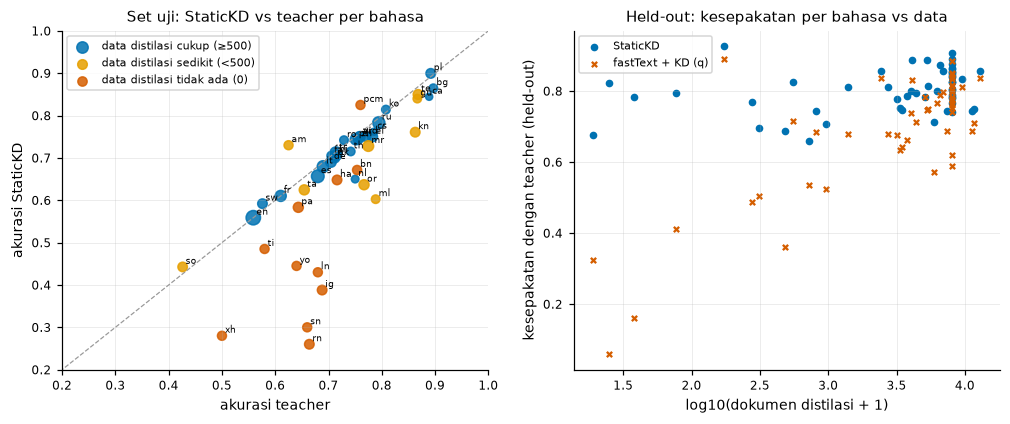

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
tier_color = {"tidak ada (0)": "#D55E00", "sedikit (<500)": "#E69F00", "cukup (≥500)": "#0072B2"}
ax = axes[0]
for tier, g in per_lang.groupby("distil_tier"):
    ax.scatter(g.teacher_acc, g.statickd_acc, s=18 + g.n / 12, color=tier_color[tier], label=f"data distilasi {tier}", alpha=0.85)
for lang, r in per_lang.iterrows():
    ax.annotate(lang, (r.teacher_acc, r.statickd_acc), fontsize=6, xytext=(2, 2), textcoords="offset points")
ax.plot([0, 1], [0, 1], color="#999999", lw=0.8, ls="--"); ax.set_xlim(0.2, 1); ax.set_ylim(0.2, 1)
ax.set_xlabel("akurasi teacher"); ax.set_ylabel("akurasi StaticKD"); ax.legend(fontsize=7, loc="upper left")
ax.set_title("Set uji: StaticKD vs teacher per bahasa")
ax = axes[1]
ax.scatter(np.log10(fac.distil_docs + 1), fac.agree, color=viz.COLORS["statickd"], s=16, label="StaticKD")
ax.scatter(np.log10(fac.distil_docs + 1), fac.agree_ft, color=viz.COLORS["fasttext"], s=12, marker="x", label="fastText + KD (q)")
ax.set_xlabel("log10(dokumen distilasi + 1)"); ax.set_ylabel("kesepakatan dengan teacher (held-out)")
ax.legend(fontsize=7); ax.set_title("Held-out: kesepakatan per bahasa vs data")
viz.show_and_save(fig, "fig_per_language")

### 10.3 Analisis per label

**F1 per label di set uji**

,teacher,statickd,ft_kd_subword_q,n,gap
society,"0,1785","0,1564","0,1620",132,"-0,0221"
disaster,"0,2661","0,2931","0,2549",78,"0,0271"
human int.,"0,3848","0,3189","0,2628",301,"-0,0659"
conflict,"0,3924","0,3698","0,3328",160,"-0,0227"
environment,"0,5476","0,3803","0,3290",278,"-0,1673"
labour,"0,4332","0,3895","0,2786",153,"-0,0436"
religion,"0,6064","0,4605","0,1776",516,"-0,1458"
arts,"0,6164","0,5354","0,4177",767,"-0,0810"
lifestyle,"0,6500","0,5738","0,3484",447,"-0,0762"
sci-tech,"0,6207","0,6006","0,5244",383,"-0,0201"


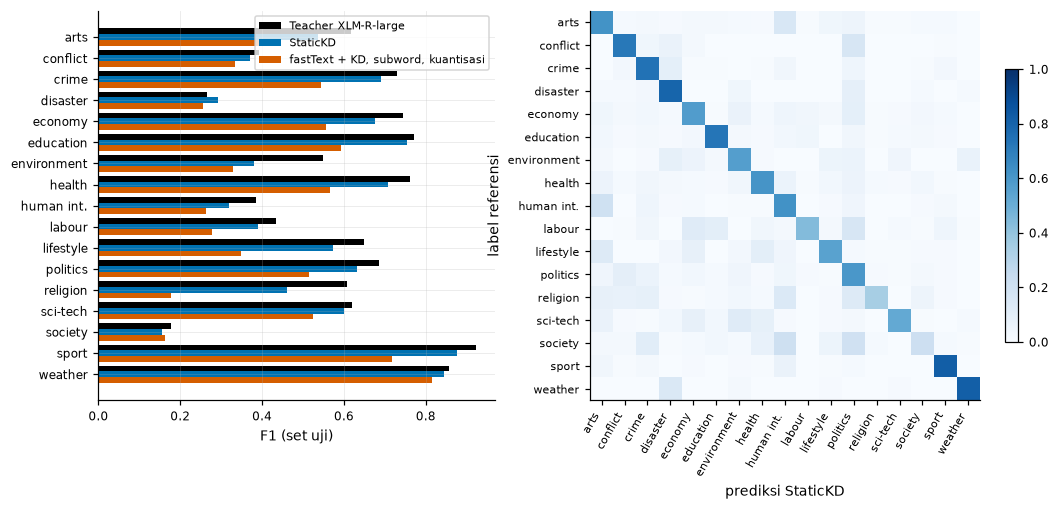

kebingungan terbesar (referensi -> prediksi): [('society', 'human int.', np.float64(0.2)), ('human int.', 'arts', np.float64(0.2)), ('society', 'politics', np.float64(0.2)), ('labour', 'politics', np.float64(0.16)), ('conflict', 'politics', np.float64(0.16))]


In [47]:
y_test = test.y.to_numpy()
label_f1 = pd.DataFrame({m: ev.per_label_f1(y_test, ev.load_pred(key(m), "test")) for m in ["teacher", "statickd", "ft_kd_subword_q"]}, index=SHORT_LABELS)
label_f1["n"] = pd.Series(y_test).value_counts().reindex(range(NUM_LABELS), fill_value=0).values
label_f1["gap"] = label_f1.statickd - label_f1.teacher
dev_view = ev.eval_view("dev")
label_f1_dev = pd.DataFrame({m: ev.per_label_f1(dev_view.y, ev.pred_view(key(m), "dev")) for m in ["teacher", "statickd"]}, index=SHORT_LABELS)
for lab, r in label_f1.iterrows():
    NUM.add(f"label.{lab.replace(' ', '').replace('.', '')}.static", r.statickd, 2); NUM.add(f"label.{lab.replace(' ', '').replace('.', '')}.teacher", r.teacher, 2)
hardest = label_f1.sort_values("statickd").head(4).index.tolist(); easiest = label_f1.sort_values("statickd", ascending=False).head(3).index.tolist()
NUM.add("label.hardest", ", ".join(f"\\eng{{{h}}} ({fmt(label_f1.loc[h, 'statickd'], 2)})" for h in hardest))
NUM.add("label.easiest", ", ".join(f"\\eng{{{h}}} ({fmt(label_f1.loc[h, 'statickd'], 2)})" for h in easiest))
biggest = label_f1.sort_values("gap").head(3).index.tolist()
NUM.add("label.biggest_gap", ", ".join(f"\\eng{{{h}}} ({fmt(label_f1.loc[h, 'gap'], 2, sign=True)})" for h in biggest))
show(label_f1.sort_values("statickd"), "F1 per label di set uji")
cm = ev.confusion(y_test, ev.load_pred("statickd", "test"), normalise=True)
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), gridspec_kw={"width_ratios": [1, 1.25]})
xx = np.arange(NUM_LABELS)
for k, m in enumerate(["teacher", "statickd", "ft_kd_subword_q"]):
    axes[0].barh(xx + (k - 1) * 0.27, label_f1[m], 0.27, color=viz.color(m), label=an.MODELS[m][0].replace(" (usulan)", ""))
axes[0].set_yticks(xx); axes[0].set_yticklabels(SHORT_LABELS); axes[0].invert_yaxis(); axes[0].set_xlabel("F1 (set uji)"); axes[0].legend(fontsize=7)
im = axes[1].imshow(cm, cmap="Blues", vmin=0, vmax=1)
axes[1].set_xticks(xx); axes[1].set_xticklabels(SHORT_LABELS, rotation=60, ha="right", fontsize=7)
axes[1].set_yticks(xx); axes[1].set_yticklabels(SHORT_LABELS, fontsize=7); axes[1].grid(False)
axes[1].set_xlabel("prediksi StaticKD"); axes[1].set_ylabel("label referensi"); fig.colorbar(im, ax=axes[1], shrink=0.7)
viz.show_and_save(fig, "fig_per_label")
off = cm.copy(); np.fill_diagonal(off, 0)
top_conf = sorted(((off[i, j], SHORT_LABELS[i], SHORT_LABELS[j]) for i in range(NUM_LABELS) for j in range(NUM_LABELS)), reverse=True)[:5]
print("kebingungan terbesar (referensi -> prediksi):", [(a, b, round(v, 2)) for v, a, b in top_conf])
NUM.add("label.top_confusions", "; ".join(f"\\eng{{{a}}} $\\rightarrow$ \\eng{{{b}}} ({fmt(v, 0, percent=True)})" for v, a, b in top_conf[:3]))

### 10.4 Kalibrasi dan mode *cascade*

Probabilitas softmax StaticKD dapat dipakai sebagai sinyal keyakinan. Dalam mode *cascade*, artikel
dengan keyakinan ≥ θ diputuskan oleh StaticKD, dan sisanya dikirim ke *teacher* ONNX int8. *Throughput*
efektif satu *core* dihitung sebagai $1/(1/r_S + (1-c)/r_T)$, dengan $r_S$ dan $r_T$ *throughput*
StaticKD dan *teacher*, serta $c$ porsi artikel yang diputuskan StaticKD.

,dev,test
statickd,0.0410,0.1390
teacher,0.0900,0.2450


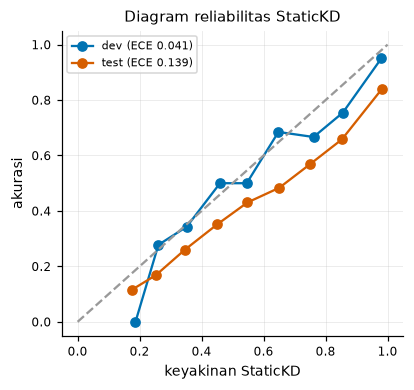

In [48]:
calib = {}
for m in ["teacher", "statickd"]:
    for s in ("dev", "test"):
        calib[(m, s)] = ev.ece(data.softmax(ev.logits_view(key(m), s)), ev.eval_view(s).y.to_numpy())
calib = pd.Series(calib).unstack()
for (m, s), v in pd.Series({(m, s): calib.loc[m, s] for m in calib.index for s in calib.columns}).items():
    NUM.add(f"ece.{m}.{s}", v, 3)
display(calib.round(3))
fig, ax = plt.subplots(figsize=(4, 3.6))
for s, c in (("dev", "#0072B2"), ("test", "#D55E00")):
    rel = ev.reliability(data.softmax(ev.logits_view("statickd", s)), ev.eval_view(s).y.to_numpy())
    ax.plot(rel.confidence, rel.accuracy, marker="o", color=c, label=f"{s} (ECE {calib.loc['statickd', s]:.3f})")
ax.plot([0, 1], [0, 1], ls="--", color="#999999"); ax.set_xlabel("keyakinan StaticKD"); ax.set_ylabel("akurasi")
ax.legend(fontsize=7); ax.set_title("Diagram reliabilitas StaticKD")
viz.show_and_save(fig, "fig_calibration")

In [49]:
p_s = data.softmax(ev.load_logits("statickd", "test")); conf = p_s.max(1); pred_s = p_s.argmax(1)
teacher_cpu = "teacher_onnx_int8" if ev.has_predictions("teacher_onnx_int8", "test") else "teacher"
pred_t = ev.load_pred(teacher_cpu, "test")
r_s, r_t = eff.loc["statickd", "docs_per_sec_1c"], eff.loc["teacher_onnx_int8", "docs_per_sec_1c"]
casc = []
for theta in [0.0, 0.5, 0.6, 0.7, 0.8, 0.9, 1.01]:
    keep = conf >= theta
    pred = np.where(keep, pred_s, pred_t)
    casc.append({"theta": theta, "coverage": keep.mean(), "acc_covered": (pred_s[keep] == y_test[keep]).mean() if keep.any() else np.nan,
                 "macro_f1": ev.macro_f1(y_test, pred), "accuracy": (pred == y_test).mean(),
                 "docs_per_sec": 1 / (1 / r_s + (1 - keep.mean()) / r_t)})
casc = pd.DataFrame(casc)
for _, r in casc.iterrows():
    k = f"casc.{str(r.theta).replace('.', '')}"
    NUM.add(f"{k}.coverage", r.coverage, 1, percent=True)
    NUM.add(f"{k}.docs_per_sec", r.docs_per_sec, 1)
    for c in ["acc_covered", "macro_f1", "accuracy"]:
        NUM.add(f"{k}.{c}", r[c], 3)
lines = []
for _, r in casc.iterrows():
    th = "0 (StaticKD saja)" if r.theta == 0 else ("\\eng{Teacher} saja" if r.theta > 1 else fmt(r.theta, 1))
    lines.append(" & ".join([th, fmt(r.coverage, 1, percent=True), fmt(r.acc_covered) if pd.notna(r.acc_covered) else "--",
                             fmt(r.macro_f1), fmt(r.accuracy), fmt(r.docs_per_sec, 1 if r.docs_per_sec < 100 else 0)]) + " \\\\")
write_table("cascade", lines)
show(casc, f"Cascade StaticKD -> {teacher_cpu} di set uji")

**Cascade StaticKD -> teacher_onnx_int8 di set uji**

,theta,coverage,acc_covered,macro_f1,accuracy,docs_per_sec
0,"0,0000","1,0000","0,6410","0,5447","0,6410","472,7020"
1,"0,5000","0,8084","0,7325","0,5861","0,6904","3,9691"
2,"0,6000","0,7400","0,7604","0,5932","0,6973","2,9321"
3,"0,7000","0,6738","0,7876","0,5996","0,7022","2,3397"
4,"0,8000","0,6026","0,8134","0,6017","0,7034","1,9220"
5,"0,9000","0,5166","0,8393","0,6018","0,7025","1,5812"
6,"1,0100","0,0000",nan,"0,5997","0,6992","0,7658"


### 10.5 Contoh kualitatif

Contoh buatan dalam beberapa bahasa, termasuk bahasa Jawa dan Sunda yang tidak ada di data distilasi,
diikuti beberapa kesalahan StaticKD di set uji yang diprediksi benar oleh *teacher*.

In [50]:
demo = {
    "id": "Pemerintah resmi menaikkan harga BBM bersubsidi mulai Sabtu. Menteri Keuangan menyebut kenaikan ini perlu untuk menjaga APBN.",
    "jv": "Tim Persebaya menang 3-1 nglawan Arema ing stadion Gelora Bung Tomo, pelatih ngendika para pemain main kanthi apik.",
    "su": "Hujan gede jeung angin puting beliung ngaruksak puluhan imah di Garut, BPBD ngungsikeun warga ka tempat anu aman.",
    "en": "Researchers at the university developed a new vaccine that reduced malaria infections by 70 percent in clinical trials.",
    "de": "Die Gewerkschaft ruft zu einem landesweiten Streik auf, um höhere Löhne für Pflegekräfte durchzusetzen.",
    "sw": "Mvua kubwa imesababisha mafuriko katika mji wa Mombasa na maelfu ya watu wamehamishwa.",
}
proba = final_model.predict_proba(list(demo.values()))
display(pd.DataFrame({"bahasa": list(demo), "teks": [t[:80] + "..." for t in demo.values()],
                      "prediksi StaticKD": [LABELS[i] for i in proba.argmax(1)], "keyakinan": proba.max(1).round(2)}))
wrong = test[(ev.load_pred("statickd", "test") != test.y) & (ev.load_pred("teacher", "test") == test.y)]
ex_rows = wrong.groupby("label_origin").head(2)
display(pd.DataFrame({"bahasa": ex_rows.lang, "asal": ex_rows.label_origin.map(an.ORIGIN_NAMES), "judul/teks": ex_rows.text.str[:90],
                      "label": ex_rows.label, "StaticKD": [LABELS[i] for i in ev.load_pred("statickd", "test")[ex_rows.index]]}))

,bahasa,teks,prediksi StaticKD,keyakinan
0,id,Pemerintah resmi menaikkan harga BBM bersubsid...,"economy, business and finance",1.0000
1,jv,Tim Persebaya menang 3-1 nglawan Arema ing sta...,sport,1.0000
2,su,Hujan gede jeung angin puting beliung ngaruksa...,"disaster, accident and emergency incident",0.9900
3,en,Researchers at the university developed a new ...,health,1.0000
4,de,Die Gewerkschaft ruft zu einem landesweiten St...,labour,1.0000
5,sw,Mvua kubwa imesababisha mafuriko katika mji wa...,"disaster, accident and emergency incident",1.0000


,bahasa,asal,judul/teks,label,StaticKD
26,en,anotasi manusia,Woman refuses to invite her brother’s boyfrien...,society,human interest
52,bn,rubrik JSON-LD,পুরোনো সম্পর্কের মানসিক অশান্তির কারণ? এই ৪ আচ...,society,human interest
58,yo,anotasi manusia,APC: Mí ò tíí ní ìpinnu lóri ìdíje ààrẹ ọdún 2...,politics,lifestyle and leisure
74,mr,kategori penerbit,सामान्यतः लोक दात स्वच्छ करण्यासाठी आणि तोंड ज...,health,environment
75,ru,rubrik JSON-LD,Как сделать французский мясной пирог с листовы...,lifestyle and leisure,"economy, business and finance"
109,bn,kategori penerbit,প্রিয় পরীক্ষার্থী গণিত বিষয় বহুনির্বাচনি প্রশ্...,education,"arts, culture, entertainment and media"


### 10.6 Ringkasan temuan

Ringkasan berikut dibangkitkan dari angka yang terkumpul di `NUM`, bukan diketik manual.

In [51]:
V = NUM.values
summary_md = f'''
| Pertanyaan | Temuan utama |
|---|---|
| RQ1 biaya | Teacher PyTorch {V['eff.teacher.latency_ms_p50_1c']} ms/artikel, ONNX int8 {V['eff.teacher_onnx_int8.latency_ms_p50_1c']} ms. StaticKD {V['eff.statickd.latency_ms_p50_1c']} ms, {V['eff.statickd.docs_per_sec_1c']} artikel/detik/core (≈{V['eff.statickd.speedup_onnx']}× teacher ONNX int8), {V['final.size']} MB, 1 juta artikel/hari = {V['eff.statickd.cores1M']} core |
| RQ2 akurasi | Set uji {V['ts.langs']} bahasa: teacher {V['teacher.test.macro']}, StaticKD {V['statickd.test.macro']} ({V['statickd.test.pct_teacher']} teacher), MiniLM {V.get('minilm_kd.test.macro', '–')}, DistilmBERT {V.get('distilmbert_kd.test.macro', '–')}, fastText+KD {V['ft_kd_subword_q.test.macro']}, TF-IDF+SVM {V.get('tfidf_svm_kd.test.macro', '–')} |
| RQ3 komponen | Tanpa data multibahasa {V['abl.emm_only.test_macro.delta']}, init acak {V['abl.random_init.test_macro.delta']}, embedding beku {V['abl.frozen.test_macro.delta']}, label keras {V['abl.hard.test_macro.delta']}, τ=2 {V['abl.tau2.test_macro.delta']} (macro-F1 uji, rata-rata seed) |
| RQ4 generalisasi | % teacher: bahasa dengan data cukup {V['grp.distil_tier.cukup.pct']}, tanpa data distilasi {V['grp.distil_tier.tidakada.pct']}; bahasa di luar XLM-R: StaticKD {V['lang.outxlmr.static_acc']} vs teacher {V['lang.outxlmr.teacher_acc']} (akurasi) |
'''
display(Markdown(summary_md.replace("\\%", "%").replace("$-$", "−")))   # LaTeX notation -> plain text


| Pertanyaan | Temuan utama |
|---|---|
| RQ1 biaya | Teacher PyTorch 2.971 ms/artikel, ONNX int8 1.239 ms. StaticKD 2,03 ms, 473 artikel/detik/core (≈616× teacher ONNX int8), 34 MB, 1 juta artikel/hari = 0,02 core |
| RQ2 akurasi | Set uji 47 bahasa: teacher 0,598, StaticKD 0,545 (91,1% teacher), MiniLM 0,566, DistilmBERT 0,534, fastText+KD 0,435, TF-IDF+SVM 0,486 |
| RQ3 komponen | Tanpa data multibahasa −0,051, init acak −0,120, embedding beku +0,014, label keras +0,005, τ=2 −0,005 (macro-F1 uji, rata-rata seed) |
| RQ4 generalisasi | % teacher: bahasa dengan data cukup 97,5%, tanpa data distilasi 72,3%; bahasa di luar XLM-R: StaticKD 0,407 vs teacher 0,643 (akurasi) |


<a id="11"></a>
## 11. Ekspor angka, tabel, dan gambar ke jurnal

Semua angka yang dikumpulkan di `NUM` ditulis ke `jurnal_latex/generated/numbers.tex`, dengan salinan
mentah di `results/final/paper_numbers.json`. Tabel LaTeX ditulis ke `jurnal_latex/generated/tab_*.tex`
dan gambar ke `jurnal_latex/figures/`. Di `main.tex`, setiap angka dipanggil dengan `\val{kunci}`. Kunci
yang tidak ada akan tercetak sebagai "??" merah di PDF.

In [52]:
path = NUM.write()
generated = sorted(p.name for p in (config.ROOT / "jurnal_latex" / "generated").glob("*.tex"))
figures = sorted(p.name for p in viz.FIG_DIR.glob("fig_*.pdf"))
print(f"{len(NUM.values)} angka -> {path}")
print("tabel:", generated)
print("gambar:", figures)

1013 angka -> D:\study\s2\kuliah\semester_2\metpen\iptc_label_class\jurnal_latex\generated\numbers.tex
tabel: ['numbers.tex', 'tab_ablation.tex', 'tab_ablation_groups.tex', 'tab_cascade.tex', 'tab_eff.tex', 'tab_factors.tex', 'tab_groups.tex', 'tab_hparams.tex', 'tab_main.tex', 'tab_sig.tex', 'tab_testset.tex']
gambar: ['fig_calibration.pdf', 'fig_distil_per_language.pdf', 'fig_ensemble_size.pdf', 'fig_groups.pdf', 'fig_latency_ram_size.pdf', 'fig_per_label.pdf', 'fig_per_language.pdf', 'fig_teacher_labels.pdf', 'fig_temperature.pdf', 'fig_temperature_example.pdf', 'fig_testset_heatmap.pdf', 'fig_tradeoff.pdf', 'fig_training_curves.pdf']


<a id="12"></a>
## 12. Keterbatasan dan catatan reproduktibilitas

**Ancaman validitas**
1. **Label silver.** 68% set uji berlabel kategori/rubrik penerbit. Pemetaannya konservatif dan tervalidasi
   terhadap pohon IPTC, tetapi tidak dianotasi ulang oleh manusia. Bagian 8.5 memberi pemeriksaan tidak
   langsung.
2. **Label "manusia" MasakhaNEWS** memakai skema MasakhaNEWS yang dipetakan ke IPTC. Hanya MN-DS yang
   dianotasi langsung dengan IPTC.
3. **Cakupan label per bahasa timpang.** Bahasa Afrika hanya mencakup 4–5 topik besar. Macro-F1 dihitung
   atas label yang hadir.
4. **Keragaman situs.** 27 bahasa praktis berasal dari satu penerbit (BBC/VOA untuk bahasa Afrika,
   L3Cube untuk bahasa India). Klaim untuk bahasa-bahasa ini terbatas pada penerbit tersebut.
5. **Batas atas *student* adalah *teacher*.** Kesalahan dan bias *teacher* ikut tertiru.
6. **Satu mesin *benchmark*.** Angka absolut di server akan berbeda, tetapi rasio antarmodel tetap
   informatif.
7. **Test set manusia Kuzman & Ljubešić tidak diakses** karena tidak publik.

**Reproduktibilitas**
- Seluruh langkah dapat diulang dengan saklar `RUN_*`. *Seed* dicatat di setiap `meta.json`.
- Versi pustaka ada di `results/final/environment.json`.
- Set uji dirilis sebagai manifest: ID/URL, label, dan asal label, tanpa teks yang berhak cipta, beserta
  skrip rekonstruksinya.